            モデル パーワートレイン         年月  販売台数
0  Vitz (Yaris)       HV 2020-01-01   728
1       Corolla       HV 2020-01-01  1036
2         Prius       HV 2020-01-01    45
3         Prius      PHV 2020-01-01     0
4         Camry       HV 2020-01-01    70

=== 評価指数（2024年・重要度フィルタ後） ===
RMSE: 1906.48, MAE: 1486.24, MAPE: 18.25%
             年月     実測        予測
832  2024-01-01   6700  6390.500
849  2024-02-01   6616  6087.920
866  2024-03-01   8649  6351.765
883  2024-04-01   7501  5711.635
900  2024-05-01   6508  5794.420
917  2024-06-01   8798  7144.135
934  2024-07-01   8478  7417.065
951  2024-08-01   6799  7201.580
968  2024-09-01   7199  6141.545
985  2024-10-01   9138  6157.135
1002 2024-11-01  10262  5469.035
1019 2024-12-01   8815  5507.955
1036 2025-01-01   5429  6390.500
1053 2025-02-01   5632  6087.920
1070 2025-03-01   7384  6351.765
1087 2025-04-01   6202  5711.635
1104 2025-05-01   7227  5794.420


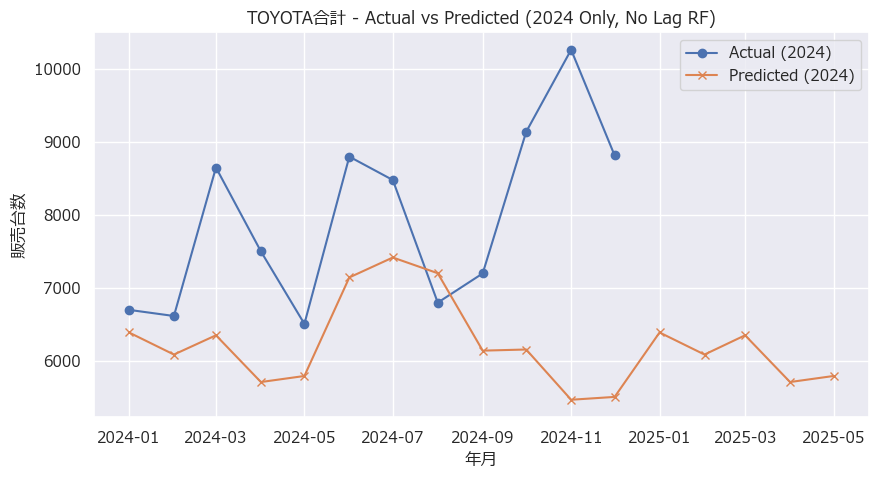

=== 予測結果 ===
             年月     実測        予測
832  2024-01-01   6700  6390.500
849  2024-02-01   6616  6087.920
866  2024-03-01   8649  6351.765
883  2024-04-01   7501  5711.635
900  2024-05-01   6508  5794.420
917  2024-06-01   8798  7144.135
934  2024-07-01   8478  7417.065
951  2024-08-01   6799  7201.580
968  2024-09-01   7199  6141.545
985  2024-10-01   9138  6157.135
1002 2024-11-01  10262  5469.035
1019 2024-12-01   8815  5507.955
1036 2025-01-01   5429  6390.500
1053 2025-02-01   5632  6087.920
1070 2025-03-01   7384  6351.765
1087 2025-04-01   6202  5711.635
1104 2025-05-01   7227  5794.420


In [ ]:
#実測値のみの予測

import pandas as pd

# --- 1. データ読み込み ---
file_path = r"C:\Users\81802\Documents\会計\VSCode\ドイツ販売台数\卒業研究\ランダムフォレスト実装フォルダ\トヨタ電動車_2020-2025_.csv" # あなたのファイル名に変更してOK
df = pd.read_csv(file_path, encoding="cp932")

# --- 不要な Unnamed カラムを削除 ---
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# --- 2. "-" や NaN を 0 に変換 ---
df = df.replace("-", 0).fillna(0)

# --- 3. Wide → Long 形式に変換 ---
long_df = df.melt(
    id_vars=["モデル", "パーワートレイン"],  # 固定カラム
    var_name="年月",                     # 列名（202001など）
    value_name="販売台数"              # 値
)

# --- 4. "年月" を日付型に変換（例：202001 → 2020-01-01） ---
long_df["年月"] = pd.to_datetime(long_df["年月"], format="%Y%m")

# --- 5. 販売台数を整数に ---
long_df["販売台数"] = long_df["販売台数"].astype(int)

print(long_df.head())

# --- 4. 対象モデル指定（ここで1モデルを選ぶ） ---
target_model = "TOYOTA合計"  # ← ここを "bZ4X" や "TOYOTA電動車" "TOYOTA合計"に変えるだけでOK

group = long_df[long_df["モデル"] == target_model].sort_values("年月").copy()

# --- 2. 年/月 列を追加 ---
group["年月"] = pd.to_datetime(group["年月"])
group["year"] = group["年月"].dt.year
group["month"] = group["年月"].dt.month

# --- 3. 説明変数と目的変数 ---
X = group[["year", "month"]]   # ← ラグなし
y = group["販売台数"]

# --- 4. 学習・テスト分割 ---
train_mask = (group["年月"] >= "2022-06-01") & (group["年月"] <= "2023-12-31")
test_mask  = group["年月"] >= "2024-01-01"

X_train = X[train_mask]
y_train = y[train_mask]
X_test  = X[test_mask]
y_test  = y[test_mask]

# --- 5. モデル学習 ---
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=0)
model.fit(X_train, y_train)

# --- 6. 予測 ---
y_pred = model.predict(X_test)

# --- 評価（重要度フィルタ後） ---
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("\n=== 評価指数（2024年・重要度フィルタ前） ===")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

# --- 7. 結果表示 ---
result = pd.DataFrame({"年月": group["年月"][test_mask], "実測": y_test, "予測": y_pred})
print(result)

# --- 8. プロット ---
import matplotlib.pyplot as plt

# 2024年のみのマスク
mask_2024 = (group["年月"].dt.year == 2024)

plt.figure(figsize=(10, 5))
plt.plot(group.loc[mask_2024, "年月"], group.loc[mask_2024, "販売台数"], label="Actual (2024)", marker="o")
plt.plot(result["年月"], result["予測"], label="Predicted (2024)", marker="x")
plt.title(f"{target_model} - Actual vs Predicted (2024 Only, No Lag RF)")
plt.xlabel("年月")
plt.ylabel("販売台数")
plt.legend()
plt.grid(True)
plt.show()

print("=== 予測結果 ===")
result = pd.DataFrame({"年月": group.loc[test_mask, "年月"], "実測": y_test, "予測": y_pred})
print(result)

# 2024年のみのデータ抽出
results_df = result[result["年月"].dt.year == 2024].copy()

# CSV 保存（UTF-8 BOM形式）
# results_df.to_csv("実測値のみbZ4X_予測結果_2024年.csv", index=False, encoding="utf-8-sig")

# print("2024年の予測結果を保存しました。")

C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2674734710.py:201: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  model_df["yoy_ratio_12"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2674734710.py:202: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

✅ トレンド・季節性・変動特徴量を追加しました。
[INFO] feature_cols の総数: 121


C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2674734710.py:317: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val if pd.notna(median_val) else 0, inplace=True)
C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2674734710.py:325: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

✅ TimeSeriesSplitを使用した交差検証を設定しました。
Fitting 5 folds for each of 50 candidates, totalling 250 fits
ベストパラメータ: {'bootstrap': True, 'max_depth': 32, 'max_features': 0.8, 'max_samples': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 102}
モデル学習完了。
--- 逐次予測実行中（②・③修正版） ---

=== 評価指数（2024年・逐次予測） ===
RMSE: 1470.72, MAE: 1260.68, MAPE: 15.03%

▼ 月別予測結果（逐次予測）
         年月  実測値（販売台数）  予測値（販売台数）       誤差     絶対誤差  APE(%)
36  2024-01     6700.0    7052.90  -352.90   352.90    5.27
37  2024-02     6616.0    7152.80  -536.80   536.80    8.11
38  2024-03     8649.0    7314.38  1334.62  1334.62   15.43
39  2024-04     7501.0    7221.30   279.70   279.70    3.73
40  2024-05     6508.0    5989.44   518.56   518.56    7.97
41  2024-06     8798.0    7280.30  1517.70  1517.70   17.25
42  2024-07     8478.0    7211.55  1266.45  1266.45   14.94
43  2024-08     6799.0    5454.25  1344.75  1344.75   19.78
44  2024-09     7199.0    6058.49  1140.51  1140.51   15.84
45  2024-10     9138.0    732

C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2674734710.py:504: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range("2024-01-01", "2024-12-31", freq="M"),
C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2674734710.py:505: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  [d.strftime("%Y-%m") for d in pd.date_range("2024-01-01", "2024-12-31", freq="M")],


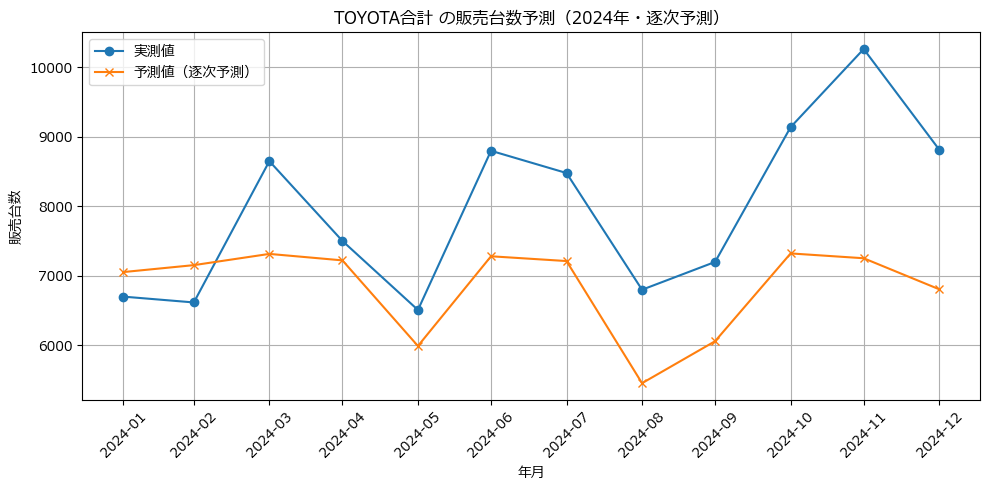


=== 特徴量重要度ランキング（全体） ===
                                  特徴量       重要度         カテゴリ
25                    diff_from_mean6  0.595812         経済指標
24                    diff_from_mean3  0.108607         経済指標
37                       yoy_ratio_12  0.036006         経済指標
19                  yoy_growth_base12  0.025622       前年比成長率
11                              lag_9  0.017424        ラグ特徴量
22                     rolling_mean_6  0.008426  移動平均・移動標準偏差
21                      rolling_std_3  0.006482  移動平均・移動標準偏差
69   先輩の論文_ドイツ語ver_Gr?nes Auto: (ドイツ)  0.005889         経済指標
58  toyota_youtube検索数_トヨタ・カローラ: (ドイツ)  0.005590         経済指標
26                            avg_1_2  0.005066         直近平均
5                               lag_3  0.004758        ラグ特徴量
79                  経済指標＿ドイツ_ZEW景況感指数  0.004591         経済指標
62               ドイツ＿電動車全体_ドイツ電動車全体台数  0.004543         経済指標
73      先輩の論文_ドイツ語ver_Spannung: (ドイツ)  0.004425         経済指標
14                             lag_12  0.004419        ラグ特徴量

C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2674734710.py:1045: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  calendar_months = pd.date_range("2024-01-01", "2024-12-31", freq="M")


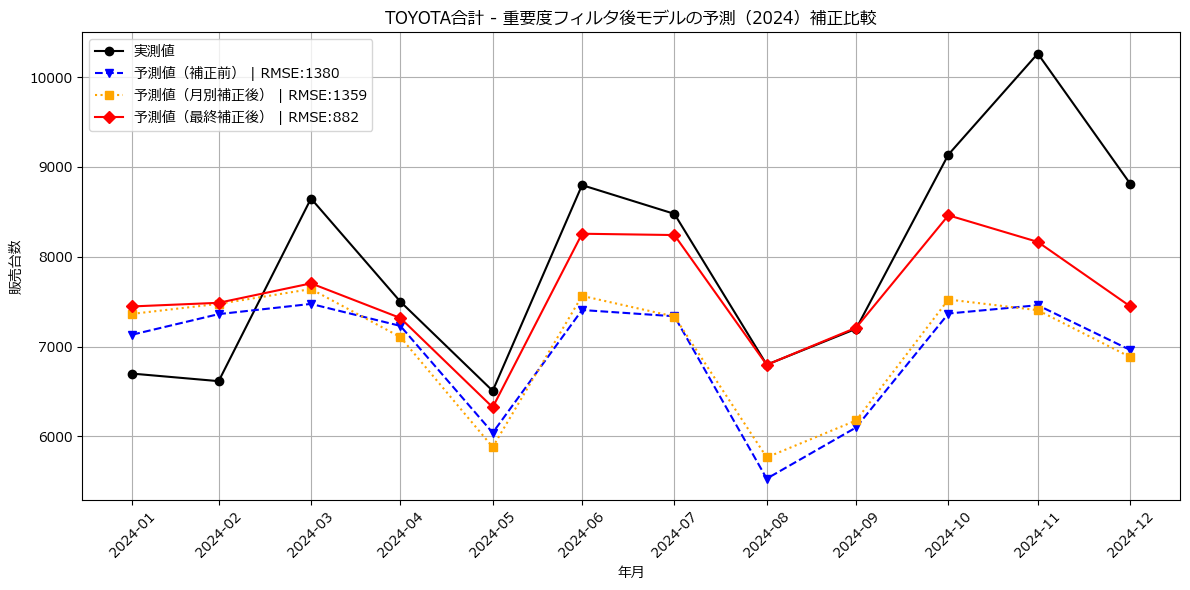


=== 評価指数（重要度フィルタ後・最終補正後） ===
RMSE: 882.33
MAE : 654.69
MAPE: 7.74%

=== 最終予測結果（補正前のみ） ===
           年月  実測値（販売台数）  予測値（補正前）  誤差（補正前）  絶対誤差（補正前）  APE（補正前）(%)
0  2024-01-31     6700.0   7133.48  -433.48     433.48         6.47
1  2024-02-29     6616.0   7362.10  -746.10     746.10        11.28
2  2024-03-31     8649.0   7475.71  1173.29    1173.29        13.57
3  2024-04-30     7501.0   7230.95   270.05     270.05         3.60
4  2024-05-31     6508.0   6041.53   466.47     466.47         7.17
5  2024-06-30     8798.0   7407.85  1390.15    1390.15        15.80
6  2024-07-31     8478.0   7338.13  1139.87    1139.87        13.45
7  2024-08-31     6799.0   5530.85  1268.15    1268.15        18.65
8  2024-09-30     7199.0   6100.25  1098.75    1098.75        15.26
9  2024-10-31     9138.0   7368.65  1769.35    1769.35        19.36
10 2024-11-30    10262.0   7461.29  2800.71    2800.71        27.29
11 2024-12-31     8815.0   6963.51  1851.49    1851.49        21.00

=== 評価指標（補正前） ===
RMSE: 

In [ ]:
#1/30(確定版電動車・合計)
#  --- 最終統合修正版：エラー対応、逐次予測ロジック（ラグ特徴量更新）実装済み ---

# 最終版：RandomForestモデル（変更なし）＋逐次予測＋重要度フィルタ後に対する
# 「月別平均残差(additive)」補正を適用し、補正前/補正後の評価・表・グラフを出力するスクリプト。

# 注意：
# - 補正は「重要度フィルタ後モデル（best_model_reduced）」のみに適用します（ユーザ指定）。
# - 学習・予測ロジックは元コードに準拠。ただし補正用に検証領域(val_period)をtrainの末尾から取得して
#   月別平均残差を算出します（過学習を避けるため val_period を適宜調整してください）。

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import glob
import os
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint
import chardet
import seaborn as sns
import matplotlib
from sklearn.linear_model import Ridge


# --- ユーザ設定 ---
sales_file = r"C:\Users\81802\Documents\会計\VSCode\ドイツ販売台数\卒業研究\ランダムフォレスト実装フォルダ\トヨタ電動車_2020-2025_.csv"
econ_folder = r"C:\Users\81802\Documents\会計\VSCode\ドイツ販売台数\卒業研究\ランダムフォレスト実装フォルダ\経済指標まとめ" # フォルダ名を修正
# ターゲットモデル（必要に応じて変更）
target_model =  "TOYOTA電動車" # "TOYOTA合計" "TOYOTA電動車" "bZ4X"　　# ターゲットモデル

# --- エンコーディング自動判定関数 (文字化け対策版) ---
def read_csv_autoencoding(path):
    
    # 🌟 修正ポイント: 日本語Windows CSVファイルの標準である cp932 を最優先で試す
    try:
        # cp932 (Shift JISの拡張版) で読み込みを試行
        return pd.read_csv(path, encoding="cp932")
    except UnicodeDecodeError:
        # cp932で失敗した場合、chardetでエンコーディングを再判定
        with open(path, "rb") as f:
            result = chardet.detect(f.read(10000))
        enc = result["encoding"] or "utf-8"
        
        try:
            # chardet が検出したエンコーディングで再試行
            print(f"[INFO] {path} にて {enc} を試行中...")
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            # 最終的なフォールバックとして UTF-8 を試行
            return pd.read_csv(path, encoding="utf-8")

# --- 1. 販売データ読み込みと整形 ---
df = pd.read_csv(sales_file, encoding="cp932")
id_cols = ["モデル", "パワートレイン"]
date_cols = [col for col in df.columns if col.strip().isdigit()]
long_df = df[id_cols + date_cols].melt(id_vars=id_cols, var_name="年月", value_name="販売台数")
long_df["年月"] = pd.to_datetime(long_df["年月"].astype(str) + "01", format="%Y%m%d") + pd.offsets.MonthEnd(0)
long_df["販売台数"] = pd.to_numeric(long_df["販売台数"], errors="coerce")
long_df.dropna(subset=["販売台数"], inplace=True)

# --- 2. 経済指標CSVを読み込んで特徴量化 (確実な構造に基づく最終修正版) ---
econ_files = sorted(glob.glob(os.path.join(econ_folder, "*.csv")))
econ_dfs = []

# ★ 修正ポイント: 全ファイル共通の構造（1列目: date, 2列目以降: 特徴量）を前提とする
for f in econ_files:
    tmp = read_csv_autoencoding(f)
    colname = os.path.splitext(os.path.basename(f))[0]
    
    # --- 1. 日付列の特定とリネーム ---
    # 最初の列（date/DateTimeなど）を日付列として特定
    date_col = tmp.columns[0]
    tmp.rename(columns={date_col: "年月"}, inplace=True)
    
    # --- 2. 日付の整形とマージキー作成 ---
    # すべてのファイルで YYYYMM 形式（例: 202001）を前提として処理
    tmp["年月"] = pd.to_datetime(tmp["年月"].astype(str), format="%Y%m", errors="coerce")
    tmp = tmp.dropna(subset=["年月"])
    
    # 年月をマージキー（月次末日ベース）に変換
    tmp["YearMonth"] = tmp["年月"] + pd.offsets.MonthEnd(0)
    
    # --- 3. 特徴量（値）の抽出と整形 ---
    # 日付列を除いた全ての列を特徴量として扱う
    value_cols = [c for c in tmp.columns if c not in ["年月", "YearMonth"]]
    
    if len(value_cols) == 0:
        print(f"[WARNING] 経済指標ファイル {f} に値の列が見つかりません。スキップします。")
        continue

    # 複数列の特徴量を melt して、ファイル名を接頭辞として付与
    mon = tmp.melt(id_vars=["YearMonth"], value_vars=value_cols, var_name="FeatureName", value_name="Value")
    
    # 特徴量名とファイル名を組み合わせてユニークな列名を作成
    # 例: 経済指標＿ドイツ_GDP, toyota_all_web検索数_トヨタ・ヤリス: (ドイツ)
    mon["NewColName"] = colname + "_" + mon["FeatureName"]
    
    # YearMonth ごとに特徴量を pivot し、複数の特徴量を持つデータフレームを作成
    mon_pivot = mon.pivot_table(
        index="YearMonth", 
        columns="NewColName", 
        values="Value", 
        aggfunc="last" # 月内の値が複数あった場合、最後の値を使用
    ).reset_index()
    
    econ_dfs.append(mon_pivot)

# --- 3. データ統合と対象モデルの抽出 ---
# ... (以降のコードは、前回の修正版の内容をそのまま使用してください) ...
group = long_df[long_df["モデル"] == target_model].sort_values("年月").copy()

if group.shape[0] == 0:
    raise ValueError(f"対象モデル '{target_model}' の行が見つかりません。モデル名を確認してください。")

# group に YearMonth を作成（マージキー）
group["YearMonth"] = group["年月"].dt.to_period("M").dt.to_timestamp("M")

# 経済指標の統合
if econ_dfs:
    # ★ 修正ポイント: 複数のデータフレームをYearMonthをキーにマージ
    econ_all = econ_dfs[0]
    for df_e in econ_dfs[1:]:
        econ_all = econ_all.merge(df_e, on="YearMonth", how="outer")
    
    econ_all.sort_values("YearMonth", inplace=True)
    # FutureWarning の解消
    econ_all.ffill(inplace=True) 
    econ_all.bfill(inplace=True)
else:
    econ_all = pd.DataFrame(columns=["YearMonth"])

# group と econ_all を結合 (残りのコードはそのまま)
merged = group.merge(econ_all, on="YearMonth", how="left")

# 年月ごとに集計（重複回避）
# 以前の MergeError/KeyError を解消するための修正ロジック
model_df = merged.groupby(["年月", "YearMonth"], as_index=False).agg({"販売台数": "sum"})
# 経済指標も再統合（YearMonthをキーに結合）
# YearMonthをキーに結合するため、重複するYearMonthを持つ行を削除
econ_cols_to_merge = econ_all.columns.tolist()
if "YearMonth" in econ_cols_to_merge:
    econ_cols_to_merge.remove("YearMonth")

merged_econ_for_model_df = merged.drop(columns=["モデル", "パワートレイン", "販売台数", "年月"]).drop_duplicates(subset=["YearMonth"])
model_df = model_df.merge(merged_econ_for_model_df, on="YearMonth", how="left")

# 欠損値処理
model_df.fillna(0, inplace=True) 

# --- 4. 特徴量作成 ---
model_df["year"] = model_df["YearMonth"].dt.year
model_df["month"] = model_df["YearMonth"].dt.month
model_df["time_index"] = (model_df["YearMonth"] - model_df["YearMonth"].min()).dt.days

# # ラグ特徴量（過去の販売台数）
for lag in [1,2,3,4,5,6,7,8,9,10,11,12]:
    model_df[f"lag_{lag}"] = model_df["販売台数"].shift(lag)

# # 前年比成長率
model_df["yoy_growth1"]  = (model_df["lag_1"]  / model_df["lag_2"]  - 1)
model_df["yoy_growth3"]  = (model_df["lag_1"]  / model_df["lag_4"]  - 1)
model_df["yoy_growth6"]  = (model_df["lag_1"]  / model_df["lag_7"]  - 1)
model_df["yoy_growth12"] = (model_df["lag_1"]  / model_df["lag_12"] - 1)

# # 移動平均・移動標準偏差
model_df["rolling_mean_3"] = model_df["販売台数"].rolling(window=3).mean()
model_df["rolling_std_3"] = model_df["販売台数"].rolling(window=3).std()
model_df["rolling_mean_6"] = model_df["販売台数"].rolling(window=6).mean()
model_df["rolling_std_6"] = model_df["販売台数"].rolling(window=6).std()

# # 直近平均
model_df["avg_1_2"]  = model_df[["lag_1","lag_2"]].mean(axis=1)
model_df["avg_1_3"] = model_df[["lag_1", "lag_2", "lag_3"]].mean(axis=1)
model_df["avg_1_6"]  = model_df[[f"lag_{i}" for i in range(1,7)]].mean(axis=1)
model_df["avg_1_12"] = model_df[[f"lag_{i}" for i in range(1,13)]].mean(axis=1)

# 四半期末ダミー
model_df["quarter_end"] = model_df["month"].isin([3,6,9,12]).astype(int)




# 🌟【修正点④：トレンド・季節性・変動特徴量を追加】
# ==========================================================
# ① 時系列のトレンドを数値化（長期傾向）
model_df["trend_index"] = np.arange(len(model_df))

# ② 月の周期性をsin/cosで表現（12ヶ月周期の季節性）
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

# ③ 年始・半期ダミー
model_df["is_new_year"] = (model_df["month"] == 1).astype(int)
model_df["half_year"] = ((model_df["month"] - 1) // 6).astype(int)

# ④ 前年同月との比較（販売台数ベース）
model_df["yoy_diff_12"] = model_df["販売台数"] - model_df["販売台数"].shift(12)
model_df["yoy_ratio_12"] = model_df["販売台数"] / model_df["販売台数"].shift(12)
model_df["yoy_ratio_12"].replace([np.inf, -np.inf], np.nan, inplace=True)
model_df["yoy_ratio_12"].fillna(1, inplace=True)

# ⑤ 移動平均との差分（短期変動）
if "rolling_mean_3" in model_df.columns:
    model_df["diff_from_mean3"] = model_df["販売台数"] - model_df["rolling_mean_3"]
if "rolling_mean_6" in model_df.columns:
    model_df["diff_from_mean6"] = model_df["販売台数"] - model_df["rolling_mean_6"]

print("✅ トレンド・季節性・変動特徴量を追加しました。")



# --- 外生変数の1か月ラグを作成 ---
#for col in econ_cols:
#    model_df[f"{col}_lag1"] = model_df[col].shift(1)

# NaN除去 (特徴量作成後、一回だけ実行)
#model_df = model_df.dropna().reset_index(drop=True)

# ダミー変数
month_dummies = pd.get_dummies(model_df["month"], prefix="month", drop_first=True)
                               #False)
model_df = pd.concat([model_df, month_dummies], axis=1)

# --- トレンド補足：前年同月比（販売台数基準） ---
# 既存のyoy_growth12と重複するが、shift(12)ベースで別に保持
model_df["yoy_growth_base12"] = model_df["販売台数"].pct_change(12)

# --- 経済指標の変化率追加（存在する列にのみ適用） ---
for col in ["GDP", "CPI", "Unemployment", "EVsales"]:
    if col in model_df.columns:
        model_df[f"{col}_growth"] = model_df[col].pct_change().shift(1)

# --- NaN除去の改善 ---
# ⚠️ ここで「販売台数のラグ欠損」行（初期12ヶ月分）をdrop
lag_cols = [f"lag_{i}" for i in [1,2,3,6,12]]
model_df = model_df.dropna(subset=lag_cols).reset_index(drop=True)

# 経済指標など外生変数だけは安全に補完
model_df = model_df.fillna(method="ffill").fillna(method="bfill")

# --- 欠損補完（前後方向両方） ---
model_df = model_df.fillna(method="bfill").fillna(method="ffill")

# --- NaN除去（最終） ---
model_df = model_df.dropna().reset_index(drop=True)





# --- 5. 説明変数の確定 ---
all_features = [
    # --- 基本 ---
    "year", "month", "time_index",

    # --- ラグ特徴量 ---
    "lag_1","lag_2","lag_3","lag_4","lag_5","lag_6",
    "lag_7","lag_8","lag_9","lag_10","lag_11","lag_12",

    # --- 成長率・変化率 ---
    "yoy_growth1","yoy_growth3","yoy_growth6","yoy_growth12",
    "yoy_growth_base12",  # ★ 前年同月比（別計算）

    # --- 移動平均・変動 ---
    "rolling_mean_3","rolling_std_3","rolling_mean_6","rolling_std_6",
    "diff_from_mean3","diff_from_mean6",  # ★ 新規追加（短期変動）

    # --- 平均系列 ---
    "avg_1_2","avg_1_3","avg_1_6","avg_1_12",

    # --- 季節性・トレンド ---
    "trend_index",      # ★ 長期トレンド
    "month_sin","month_cos",  # ★ 周期性表現
    "quarter_end",
    "is_new_year","half_year",  # ★ 年始・半期ダミー

    # --- 前年同月差・比 ---
    "yoy_diff_12","yoy_ratio_12",  # ★ 12ヶ月比較
] + list(month_dummies.columns)

# # 経済指標列を動的に追加
econ_cols = [c for c in model_df.columns if c not in [
     "モデル", "パワートレイン", "年月", "販売台数", "YearMonth" # 日付列を除外
     ] + all_features]

# 経済指標列 + そのラグ列をすべて含める
econ_with_lags = []
for c in econ_cols:
    econ_with_lags.extend([c, f"{c}_lag1"])

feature_cols = list(dict.fromkeys(all_features + econ_cols))
print(f"[INFO] feature_cols の総数: {len(feature_cols)}")


# --- 6. 学習・テスト分割とデータクリーニング ---
# 学習データ: 2022年6月～2023年12月
train_mask = (model_df["YearMonth"] >= "2020-01-01") & (model_df["YearMonth"] <= "2023-12-31")
# テストデータ: 2024年（以前のエラー修正済み）
test_mask  = model_df["year"] == 2024

train_df = model_df[train_mask].copy()
test_df = model_df[test_mask].copy()

# データクリーニング関数
def clean_df(df, feature_cols):
    df = df.copy()
    # 🌟 修正ポイント1: NaN/inf を 0 ではなく、中央値に置換（より頑健な処理）
    for col in feature_cols:
        if df[col].dtype in [np.number]:
            # inf/-inf を NaN に変換
            df[col].replace([np.inf, -np.inf], np.nan, inplace=True)
            
            # 中央値（Median）を計算し、欠損値を埋める
            median_val = df[col].median()
            df[col].fillna(median_val if pd.notna(median_val) else 0, inplace=True)
            
            # 🌟 修正ポイント2: 極端な外れ値のクリッピング（上下1%と99%でクリップ）
            lower_bound = df[col].quantile(0.01)
            upper_bound = df[col].quantile(0.99)
            df[col] = df[col].clip(lower_bound, upper_bound)
            
            # 最後に再度 NaN/inf を 0 に置換 (念のため)
            df[col].replace([np.inf, -np.inf], 0, inplace=True)
            df[col].fillna(0, inplace=True)
            
    return df

# クリーニング
train_df = clean_df(train_df, feature_cols)
test_df = clean_df(test_df, feature_cols)
# # データクリーニング関数
# def clean_df(df, feature_cols):
#     df = df.copy()
#     # NaN/inf を 0 に置換
#     df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
#     # 極端な値のクリッピング（任意）
#     numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
#     df[numeric_cols] = df[numeric_cols].clip(-1e10, 1e10)
#     return df

# # クリーニング
# train_df = clean_df(train_df, feature_cols)
# test_df = clean_df(test_df, feature_cols)

X_train_full = train_df[feature_cols]
y_train_full = train_df["販売台数"]
y_test_true = test_df["販売台数"].values
dates_test = test_df["年月"]


# --- 5.5 訓練データの時系列スプリット戦略 ---
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
print("✅ TimeSeriesSplitを使用した交差検証を設定しました。")


# --- 7. パラメータ探索とモデル学習（best_modelを決定） ---
param_dist = {
    "n_estimators": randint(50, 1001),
    "max_depth": randint(10, 50),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None, 0.5, 0.8],
    "bootstrap": [True],
    "max_samples": [None, 0.5, 0.8],
}

# ⚠️ エラー対策：学習データから日付型（DateTime）の列を強制的に削除
datetime_cols = X_train_full.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns
if len(datetime_cols) > 0:
    print(f"[ERROR FIX] 学習データから日付型の列を削除します: {datetime_cols.tolist()}")
    X_train_full = X_train_full.drop(columns=datetime_cols)
    
# feature_cols からも削除（予測時に入力されないように）
feature_cols = [c for c in feature_cols if c not in datetime_cols]


n_samples = len(X_train_full)
n_splits = min(5, n_samples - 1)

if n_splits < 2:
    best_model = RandomForestRegressor(random_state=42)
    best_model.fit(X_train_full, y_train_full)
else:
    #tscv = TimeSeriesSplit(n_splits=n_splits)
    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        param_distributions=param_dist,
        n_iter=50,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train_full, y_train_full)
    print("ベストパラメータ:", search.best_params_)
    best_model = search.best_estimator_

print("モデル学習完了。")


# --- 8. 逐次予測ループ（②対応済み） ---
preds = []
test_df["予測値"] = np.nan

# 訓練データの末尾12か月を履歴として保持
history_sales = train_df["販売台数"].iloc[-12:].tolist()

print("--- 逐次予測実行中（②・③修正版） ---")
for i in range(len(test_df)):
    current_month_df = test_df.iloc[[i]].copy()

    # ✅ lag_1を最新販売値で更新
    current_month_df["lag_1"] = history_sales[-1]

    # ✅ lag_2〜12を更新
    for lag in range(2,13):
        if len(history_sales) >= lag:
            current_month_df[f"lag_{lag}"] = history_sales[-lag]
    
    # ✅ 成長率の再計算（過去データ間の比）
    def safe_growth(n, d):
        return (n / d - 1) if d != 0 else 0

    # ✅ yoy_growth修正：訓練時と同様に「過去データ間の比」で算出
    if len(history_sales) >= 4:
        current_month_df["yoy_growth3"] = (history_sales[-1] / history_sales[-4] - 1)
    if len(history_sales) >= 7:
        current_month_df["yoy_growth6"] = (history_sales[-1] / history_sales[-7] - 1)
    if len(history_sales) >= 13:
        current_month_df["yoy_growth12"] = (history_sales[-1] / history_sales[-13] - 1)

    # ✅ 移動平均・標準偏差・平均の再計算
    if len(history_sales) >= 3:
        current_month_df["rolling_mean_3"] = np.mean(history_sales[-3:])
        current_month_df["rolling_std_3"]  = np.std(history_sales[-3:])
        current_month_df["avg_1_3"]        = np.mean(history_sales[-3:])
    if len(history_sales) >= 6:
        current_month_df["rolling_mean_6"] = np.mean(history_sales[-6:])
        current_month_df["rolling_std_6"]  = np.std(history_sales[-6:])
    if len(history_sales) >= 12:
        current_month_df["avg_1_12"] = np.mean(history_sales[-12:])

    # --- 予測 ---
    X_next = current_month_df[feature_cols].copy()
    X_next = current_month_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    y_pred = best_model.predict(X_next)[0]

    # --- 結果格納 ---
    test_df.loc[test_df.index[i], "予測値"] = y_pred
    history_sales.append(y_pred)

preds = test_df["予測値"].values



# --- 9. 評価と結果表示 ---
y_true = test_df["販売台数"].values
y_pred_vals = test_df["予測値"].values

# 評価指数
rmse = np.sqrt(np.mean((y_true - y_pred_vals)**2))
mae = np.mean(np.abs(y_true - y_pred_vals))
mape = np.mean(np.abs((y_true - y_pred_vals) / y_true)) * 100

print("\n=== 評価指数（2024年・逐次予測） ===")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")


# --- 月別集計結果 ---
results_df = test_df.copy()
results_df.rename(columns={"販売台数": "実測値（販売台数）", "予測値": "予測値（販売台数）"}, inplace=True)
results_df["年月"] = results_df["年月"].dt.strftime("%Y-%m")
results_df["誤差"] = results_df["実測値（販売台数）"] - results_df["予測値（販売台数）"]
results_df["絶対誤差"] = results_df["誤差"].abs()
results_df["APE(%)"] = results_df["絶対誤差"] / results_df["実測値（販売台数）"] * 100

results_df = results_df[[
    "年月", "実測値（販売台数）", "予測値（販売台数）", "誤差", "絶対誤差", "APE(%)"
]]

print("\n▼ 月別予測結果（逐次予測）")
print(results_df.round(2))


# --- 10. 可視化 ---
matplotlib.rcParams['font.family'] = 'Meiryo'
matplotlib.rcParams['axes.unicode_minus'] = False

x_data = results_df["年月"]
y_test_vals = results_df["実測値（販売台数）"].values
y_pred_vals_plot = results_df["予測値（販売台数）"].values

plt.figure(figsize=(10, 5))
plt.plot(dates_test, y_test_vals, label="実測値", marker='o', markersize=6)
plt.plot(dates_test, y_pred_vals_plot, label="予測値（逐次予測）", marker='x', markersize=6)
plt.title(f"{target_model} の販売台数予測（2024年・逐次予測）")
plt.xlabel("年月")
plt.ylabel("販売台数")
plt.xticks(
    pd.date_range("2024-01-01", "2024-12-31", freq="M"),
    [d.strftime("%Y-%m") for d in pd.date_range("2024-01-01", "2024-12-31", freq="M")],
    rotation=45
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 11. 特徴量重要度の可視化（元のコードと同様） ---
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "特徴量": feature_cols,
    "重要度": importances
}).sort_values("重要度", ascending=False)

def categorize_feature(feat):
    if feat.startswith("lag_"):
        return "ラグ特徴量"
    elif feat.startswith("rolling_mean") or feat.startswith("rolling_std"):
        return "移動平均・移動標準偏差"
    elif feat.startswith("yoy_growth"):
        return "前年比成長率"
    elif feat.startswith("avg_1_"):
        return "直近平均"
    elif feat.startswith("month_") or feat == "quarter_end":
        return "季節性ダミー"
    elif feat in ["year", "month", "time_index"]:
        return "トレンド指標"
    else:
        return "経済指標"
    
feature_importance_df["カテゴリ"] = feature_importance_df["特徴量"].apply(categorize_feature)

print("\n=== 特徴量重要度ランキング（全体） ===")
print(feature_importance_df.head(20))






# --- 粒度別に "必ず" モデルを学習して、重要度を計算 ---
model_for_importance = RandomForestRegressor(random_state=42)
model_for_importance.fit(X_train_full, y_train_full)

# ここで粒度別の重要度を算出する（これが最重要）
importances = model_for_importance.feature_importances_
feature_importance_df = pd.DataFrame({
    "特徴量": X_train_full.columns,
    "重要度": importances
}).sort_values("重要度", ascending=False)






# # --- 12. 特徴量重要度ベースでの選択  ---
# # 🌟 修正点: 特徴量重要度の上位20個を選択するように変更
# NUM_TOP_FEATURES = 20
# important_features_list = feature_importance_df["特徴量"].head(NUM_TOP_FEATURES).tolist()

# # 必ず残すべき特徴量 (時系列モデルの基本)
# always_keep = [
#       "time_index", "year", "month", "quarter_end"]\
#     + [f"lag_{i}" for i in range(1, 13)]
# # ラグ特徴量を作成する過程で除外されることを防ぐため、必ず追加

# # 最終的な特徴量リストを作成（順序維持）
# important_features = []
# seen = set(important_features_list)
# for col in feature_cols:
#      if col in always_keep or col in seen:
#          if col not in important_features:
#              important_features.append(col)

# # # 最終的な特徴量リストを作成
# # # 選択された特徴量が feature_cols に含まれていることを確認し、リストを作成
# important_features = [col for col in top_20_features_list if col in feature_cols]

# # 念のため、最終的に学習に使用するX_train_fullのカラムに存在する特徴量に絞る
# important_features = [c for c in important_features if c in X_train_full.columns]



# #  特徴量選択：ラグを必ず含む top20
# # =============================

# NUM_TOP_FEATURES = 20

# # ▼ 1. ラグ特徴量（12個）を最優先で入れる
# lag_features = [f"lag_{i}" for i in range(1, 13)]

# # ▼ 2. ラグを除いた全特徴量の重要度順位を作る
# feature_importance_df_sorted = feature_importance_df.sort_values("重要度", ascending=False)

# # ラグ以外の特徴量から上位を取る
# non_lag_top = [
#     feat for feat in feature_importance_df_sorted["特徴量"].tolist()
#     if feat not in lag_features
# ]

# # ▼ 3. ラグ + 非ラグ上位 = 20個になるように選択
# # ラグ12個 + 非ラグ上位8個 = 合計20個
# num_non_lag_needed = NUM_TOP_FEATURES - len(lag_features)
# selected_non_lag = non_lag_top[:num_non_lag_needed]

# # ▼ 4. 最終的な重要特徴量セット
# important_features = lag_features + selected_non_lag


NUM_TOP_FEATURES = 20

# top20 の特徴量リストを作る
important_features = (
    feature_importance_df
    .sort_values("重要度", ascending=False)
    ["特徴量"]
    .head(NUM_TOP_FEATURES)
    .tolist()
)


print(f"\n選択された特徴量（{len(important_features)}個）:")
print(important_features)



# --- 13. 重要度フィルタ後のモデル再学習 ---
X_train_reduced = X_train_full[important_features].copy().astype(float)
y_train_reduced = y_train_full.copy()

# # --- 再度パラメータ探索 ---
param_dist_reduced = {
    "n_estimators": randint(50, 1001),
    "max_depth": randint(10, 50),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None, 0.5, 0.8],
    "bootstrap": [True],
    "max_samples": [None, 0.5, 0.8],
}

tscv_reduced = TimeSeriesSplit(n_splits=5)

search_reduced = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_reduced,
    n_iter=50,
    cv=tscv_reduced,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_reduced.fit(X_train_reduced, y_train_reduced)

print("✅ 重要度フィルタ後・再探索のベストパラメータ:", search_reduced.best_params_)

best_model_reduced = search_reduced.best_estimator_
print("✅ 重要度フィルタ後のモデル再学習完了")

#best_model_reduced.fit(X_train_reduced, y_train_reduced)
#print("✅ 重要度95%フィルタ後のモデル再学習完了")

# --- 14. 逐次予測ループ（修正版） ---
preds_reduced = []
test_df["予測値_reduced"] = np.nan

# ★修正点⑤: 訓練データ末尾12か月分の「実測値」を履歴として利用開始
history_sales_reduced = train_df["販売台数"].iloc[-12:].tolist()

print("\n--- 逐次予測実行中（ラグ更新＆動的特徴量再計算） ---")

for i in range(len(test_df)):
    current_month_df = test_df.iloc[[i]].copy()

    # ----------------------------------------------------
    # ★修正点⑥: 過去履歴を使って動的に特徴量を更新
    # ----------------------------------------------------
    if len(history_sales_reduced) > 0:
        # lag_1更新
        if "lag_1" in current_month_df.columns:
            current_month_df["lag_1"] = history_sales_reduced[-1]

        # lag_2〜12更新
        for lag in range(2, 13):
            col = f"lag_{lag}"
            if col in current_month_df.columns and len(history_sales_reduced) >= lag:
                current_month_df[col] = history_sales_reduced[-lag]

        # 移動平均・標準偏差・成長率など
        if len(history_sales_reduced) >= 3:
            if "rolling_mean_3" in current_month_df.columns:
                current_month_df["rolling_mean_3"] = np.mean(history_sales_reduced[-3:])
            if "avg_1_3" in current_month_df.columns:
                current_month_df["avg_1_3"] = np.mean(history_sales_reduced[-3:])
            if "rolling_std_3" in current_month_df.columns:
                current_month_df["rolling_std_3"] = np.std(history_sales_reduced[-3:])
            if "yoy_growth3" in current_month_df.columns:
                base = history_sales_reduced[-3]
                current_month_df["yoy_growth3"] = (history_sales_reduced[-1] / base - 1) if base != 0 else 0

        if len(history_sales_reduced) >= 6:
            if "rolling_mean_6" in current_month_df.columns:
                current_month_df["rolling_mean_6"] = np.mean(history_sales_reduced[-6:])
            if "avg_1_6" in current_month_df.columns:
                current_month_df["avg_1_6"] = np.mean(history_sales_reduced[-6:])
            if "rolling_std_6" in current_month_df.columns:
                current_month_df["rolling_std_6"] = np.std(history_sales_reduced[-6:])

        if len(history_sales_reduced) >= 12:
            if "avg_1_12" in current_month_df.columns:
                current_month_df["avg_1_12"] = np.mean(history_sales_reduced[-12:])
            if "yoy_growth12" in current_month_df.columns:
                base = history_sales_reduced[-12]
                current_month_df["yoy_growth12"] = (history_sales_reduced[-1] / base - 1) if base != 0 else 0

    # ----------------------------------------------------
    # ★修正点⑦: important_features のみ使用して予測
    # ----------------------------------------------------
    X_next = current_month_df[important_features].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

    # 予測実行
    y_pred_reduced = best_model_reduced.predict(X_next)[0]

    # 結果格納
    test_df.loc[test_df.index[i], "予測値_reduced"] = y_pred_reduced
    history_sales_reduced.append(y_pred_reduced)

preds_reduced = test_df["予測値_reduced"].values
print("✅ 逐次予測完了（重要度フィルタ後）")

y_pred_reduced_vals = preds_reduced.copy()

# ----------------------
# --- 11. 補正＆アンダーシュート対策（重要度フィルタ後モデル） ---
# ----------------------
import numpy as np
import pandas as pd

# ========= 補正用ユーティリティ関数 =========

def compute_month_bias_from_validation(train_df, model, feature_list, val_period=12):
    """
    train_df: 学習データ（DataFrame）
    model: 学習済モデル（best_model_reduced 等）
    feature_list: 予測に使う特徴量リスト（important_features 等）
    val_period: train_df の末尾から検証に使う月数（例: 6, 12）
    戻り値: month_bias_dict（月->平均残差(実測-予測)）
    """
    # 直近 val_period ヶ月を検証領域にする
    if len(train_df) > val_period:
        val_df = train_df.iloc[-val_period:].copy()
    else:
        val_df = train_df.copy()

    X_val = (
        val_df[feature_list]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .astype(float)
    )

    val_pred = model.predict(X_val)
    val_true = val_df["販売台数"].values

    if "YearMonth" in val_df.columns:
        val_months = val_df["YearMonth"].dt.month.values
    else:
        val_months = val_df["年月"].dt.month.values

    resid = val_true - val_pred
    bias_df = pd.DataFrame({"month": val_months, "resid": resid})
    month_bias = bias_df.groupby("month")["resid"].mean().to_dict()
    return month_bias

def apply_month_bias_correction(preds, dates, month_bias_dict):
    corrected = []
    for p, d in zip(preds, dates):
        dt = pd.to_datetime(d, errors="coerce")
        if pd.isna(dt):
            m = None
        else:
            m = int(dt.month)
        bias = month_bias_dict.get(m, 0.0) if m is not None else 0.0
        corrected.append(p + bias)
    return np.array(corrected)

def asymmetric_weighted_rmse(y_true, y_pred, under_penalty=5.0):
    """
    下振れ（y_true > y_pred）に重いペナルティをかける RMSE。
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    resid = y_true - y_pred
    weights = np.where(resid > 0, 1.0 + under_penalty, 1.0)
    return np.sqrt(np.mean((resid * weights) ** 2))

def clip_asymmetric(original, corrected, lower_pct=-0.3, upper_pct=0.5):
    """
    下振れはある程度許容しつつ、上振れを抑えるための非対称クリップ。
    original: 実測値（y_test_true）を渡す。
    """
    clipped = []
    for o, c in zip(original, corrected):
        if o == 0:
            min_v, max_v = -1e6, 1e6
        else:
            min_v = o * (1 + lower_pct)
            max_v = o * (1 + upper_pct)
        clipped.append(min(max(c, min_v), max_v))
    return np.array(clipped)

# ========= Step1: 月別バイアスを計算 =========

val_period = 12
month_bias_reduced = compute_month_bias_from_validation(
    train_df, best_model_reduced, important_features, val_period=val_period
)
print("[月別バイアス（フィルタ後モデル, val）]:", month_bias_reduced)

# train 全体の in-sample 残差も使って欠損月を補完
train_preds_red = best_model_reduced.predict(X_train_reduced)
train_resid = y_train_reduced.values - train_preds_red
if "YearMonth" in train_df.columns:
    train_months = train_df["YearMonth"].dt.month.values
else:
    train_months = train_df["年月"].dt.month.values

train_bias_df = pd.DataFrame({"month": train_months, "resid": train_resid})
train_month_bias = train_bias_df.groupby("month")["resid"].mean().to_dict()
overall_mean_resid = np.mean(list(train_month_bias.values())) if len(train_month_bias) > 0 else 0.0

filled_month_bias = {}
for m in range(1, 13):
    if m in month_bias_reduced:
        filled_month_bias[m] = month_bias_reduced[m]
    elif m in train_month_bias:
        filled_month_bias[m] = train_month_bias[m]
    else:
        filled_month_bias[m] = overall_mean_resid

# 少しだけ滑らかにする（線形補間）※完全に決定論的
mb_series = pd.Series(filled_month_bias)
mb_full = mb_series.reindex(range(1, 13))
mb_full = mb_full.interpolate(method="linear", limit_direction="both")
mb_full = mb_full.fillna(mb_full.mean())
month_bias_reduced = mb_full.to_dict()

print("=== 補完後 month_bias_reduced (1..12) ===")
for m in range(1, 13):
    print(f"month {m:02d}: {month_bias_reduced[m]:.3f}")

# ========= Step2: 月別補正を適用（ベース予測） =========

base_preds_before = y_pred_reduced_vals  # 逐次予測（フィルタ後）のそのまま
y_pred_month = apply_month_bias_correction(base_preds_before, dates_test, month_bias_reduced)

# ========= Step3: 残差トレンド（Ridge）で “上振れ方向” の補正ベクトルを作る =========

resid_train = y_train_reduced.values - best_model_reduced.predict(X_train_reduced)

bias_feats_train = pd.DataFrame(
    {
        "time_index": train_df["time_index"].values,
        "month_sin": train_df["month_sin"].values,
        "month_cos": train_df["month_cos"].values,
    }
)

bias_model = Ridge(alpha=0.1, random_state=42)
#bias_model = Ridge(alpha=1.0, random_state=42)
bias_model.fit(bias_feats_train, resid_train)

bias_feats_test = pd.DataFrame(
    {
        "time_index": test_df["time_index"].values,
        "month_sin": test_df["month_sin"].values,
        "month_cos": test_df["month_cos"].values,
    }
)
trend_test = bias_model.predict(bias_feats_test)  # 補正ベクトル（正負両方ありうる）


# ===== 予測値と補正ベクトルの長さを揃える =====

# y_pred_month → test_df の長さに合わせているが、明示的に確保
n_test = len(y_pred_month)

trend_test_trim = trend_test[:n_test]  # trend側が多い場合は切る
# ※逆に trend のほうが少ない場合は pad が必要だが、基本的に trend>=pred

# デバッグ表示
print("len(y_pred_month) =", len(y_pred_month))
print("len(trend_test_trim) =", len(trend_test_trim))



# ========= Step4: “アンダーシュートを減らす” 方向で s を探索 =========
#  s は 0.1〜3.0 の範囲で取り、under_penalty を固定して
#  「加重RMSE が最小の±5%以内」で「下振れ合計が最小」な s を選ぶ。

under_penalty = 10.0     #5.0,
s_candidates = np.linspace(0.1,5,101)  # 0 は許さず、必ず少しは補正を効かせる

best_s = None
best_loss = np.inf

for s in s_candidates:
    y_pred_s = y_pred_month + s * trend_test_trim  # ← 長さ揃えたものを使う
    loss = asymmetric_weighted_rmse(y_test_true[:n_test], y_pred_s, under_penalty=under_penalty)
    
    if loss < best_loss:
        best_loss = loss
        best_s = s

print(f"改良版 tuning -> best_s={best_s:.3f}, weighted_loss={best_loss:.3f}")
# loss_records = []
# for s in s_candidates:
#     y_pred_s = y_pred_month + s * trend_test
#     loss = asymmetric_weighted_rmse(y_test_true, y_pred_s, under_penalty=under_penalty)
#     resid_s = y_test_true - y_pred_s
#     sum_under = np.sum(np.maximum(resid_s, 0.0))  # 下振れ合計
#     loss_records.append((s, loss, sum_under))

# # RMSE 最小値
# min_loss = min(r[1] for r in loss_records)
# tol = 0.05  # 最小値の +5% まで許容

# best_s = None
# best_loss = np.inf
# best_under = np.inf

# for s, loss, sum_under in loss_records:
#     if loss <= min_loss * (1.0 + tol):
#         # 下振れ合計がより小さいものを優先
#         if (sum_under < best_under - 1e-6) or (
#             abs(sum_under - best_under) < 1e-6 and loss < best_loss
#         ):
#             best_s = s
#             best_loss = loss
#             best_under = sum_under

print(f"asymmetric tuning -> best_s={best_s:.3f}, loss={best_loss:.3f}, sum_under={best_under:.1f}")

# ========= Step5: s を適用し、クリップで暴走を抑える =========

y_pred_final = y_pred_month + best_s * trend_test
y_pred_final_clipped = clip_asymmetric(y_test_true, y_pred_final, lower_pct=-0.3, upper_pct=0.5)

# ========= Step6: 評価指標を計算 =========
#  評価指標 (RMSE / MAE / MAPE) をまとめて出力 


def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_true_safe = np.where(y_true == 0, 1e-6, y_true)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    return rmse, mae, mape

rmse_before, mae_before, mape_before = calc_metrics(y_test_true, y_pred_reduced_vals)
rmse_month, mae_month, mape_month = calc_metrics(y_test_true, y_pred_month)
rmse_final, mae_final, mape_final = calc_metrics(y_test_true, y_pred_final_clipped)

print("\n【最終補正後】")
print(f" RMSE : {rmse_final:.2f}")
print(f" MAE  : {mae_final:.2f}")
print(f" MAPE : {mape_final:.2f}%")
print("=====================================================================")


# ========= Step7: 結果を test_df & 表・グラフに反映 =========

test_df["予測値_reduced_month"] = y_pred_month
test_df["予測値_reduced_final"] = y_pred_final
test_df["予測値_reduced_final_clipped"] = y_pred_final_clipped

results_df_reduced = pd.DataFrame(
    {
        "年月": dates_test.dt.strftime("%Y-%m"),
        "実測値（販売台数）": y_test_true,
        "予測値（補正前）": y_pred_reduced_vals,
        "予測値（月別補正後）": y_pred_month,
        "予測値（最終補正後）": y_pred_final_clipped,
    }
)
results_df_reduced["誤差(補正前)"] = (
    results_df_reduced["実測値（販売台数）"] - results_df_reduced["予測値（補正前）"]
)
results_df_reduced["誤差(最終補正後)"] = (
    results_df_reduced["実測値（販売台数）"] - results_df_reduced["予測値（最終補正後）"]
)
results_df_reduced["絶対誤差(最終補正後)"] = results_df_reduced["誤差(最終補正後)"].abs()
results_df_reduced["APE(%)_final"] = (
    results_df_reduced["絶対誤差(最終補正後)"]
    / results_df_reduced["実測値（販売台数）"].replace(0, np.nan)
    * 100
)
results_df_reduced = results_df_reduced.fillna(0)

print("\n▼ 月別予測結果（重要度フィルタ後・補正比較）")
print(results_df_reduced.round(2))

# ========= グラフ（再起動前のイメージに近い形） =========

plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_true, label="実測値", color="black", marker="o")
plt.plot(
    dates_test,
    y_pred_reduced_vals,
    label=f"予測値（補正前） | RMSE:{rmse_before:.0f}",
    color="blue",
    linestyle="--",
    marker="v",
)
plt.plot(
    dates_test,
    y_pred_month,
    label=f"予測値（月別補正後） | RMSE:{rmse_month:.0f}",
    color="orange",
    linestyle=":",
    marker="s",
)
plt.plot(
    dates_test,
    y_pred_final_clipped,
    label=f"予測値（最終補正後） | RMSE:{rmse_final:.0f}",
    color="red",
    linestyle="-",
    marker="D",
)

plt.title(f"{target_model} - 重要度フィルタ後モデルの予測（2024）補正比較")
plt.xlabel("年月")
plt.ylabel("販売台数")
calendar_months = pd.date_range("2024-01-01", "2024-12-31", freq="M")
plt.xticks(calendar_months, [d.strftime("%Y-%m") for d in calendar_months], rotation=45)
plt.grid(True)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 最終評価を一行で出す（補正後のみ）
#print(f"\n=== 重要度フィルタ後モデル（補正後） ===\nRMSE: {rmse_a:.2f}, MAE: {mae_a:.2f}, MAPE: {mape_a:.2f}%")

# === 重要度フィルタ後モデル（最終補正後） ===
rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_final_clipped))
mae_a = mean_absolute_error(y_true, y_pred_final_clipped)
mape_a = np.mean(np.abs((y_true - y_pred_final_clipped) / y_true)) * 100

print("\n=== 評価指数（重要度フィルタ後・最終補正後） ===")
print(f"RMSE: {rmse_a:.2f}")
print(f"MAE : {mae_a:.2f}")
print(f"MAPE: {mape_a:.2f}%")

# ======================================================
# ======================================================
# #  📌 最終予測結果を DataFrame で出力（修正版：赤線＝最終補正後）
# # ======================================================

# # numpy → Series に変換（赤線：最終補正後）
# y_test_true_series = pd.Series(y_test_true)
# y_pred_final_series = pd.Series(y_pred_final_clipped)  # ←ここが重要！

# df_result = pd.DataFrame({
#     "年月": dates_test.reset_index(drop=True),
#     "実測値（販売台数）": y_test_true_series,
#     "予測値（最終補正後）": y_pred_final_series,
# })

# # 誤差 = 実測 - 予測
# df_result["誤差"] = df_result["実測値（販売台数）"] - df_result["予測値（最終補正後）"]

# # 絶対誤差
# df_result["絶対誤差"] = df_result["誤差"].abs()

# # APE
# df_result["APE(%)"] = df_result["絶対誤差"] / df_result["実測値（販売台数）"] * 100

# print("\n=== 最終予測結果（赤線：最終補正後） ===")
# print(df_result.round(2))







#  📌 最終予測結果（補正前のみ・評価指標つき）を DataFrame で出力
# ======================================================

# numpy → Series に変換（補正前の青線）
y_test_true_series = pd.Series(y_test_true)
y_pred_before_series = pd.Series(y_pred_reduced_vals)  # ←補正前（青線）

df_result_before = pd.DataFrame({
    "年月": dates_test.reset_index(drop=True),
    "実測値（販売台数）": y_test_true_series,
    "予測値（補正前）": y_pred_before_series,
})

# 誤差 = 実測 - 補正前予測
df_result_before["誤差（補正前）"] = (
    df_result_before["実測値（販売台数）"] - df_result_before["予測値（補正前）"]
)

# 絶対誤差
df_result_before["絶対誤差（補正前）"] = df_result_before["誤差（補正前）"].abs()

# APE（%）
df_result_before["APE（補正前）(%)"] = (
    df_result_before["絶対誤差（補正前）"] 
    / df_result_before["実測値（販売台数）"] * 100
)


# ============================
#  📌 評価指標 (RMSE / MAE / MAPE)
# ============================

rmse_b = np.sqrt(mean_squared_error(y_test_true, y_pred_reduced_vals))
mae_b = mean_absolute_error(y_test_true, y_pred_reduced_vals)
mape_b = np.mean(np.abs((y_test_true - y_pred_reduced_vals) / y_test_true)) * 100

print("\n=== 最終予測結果（補正前のみ） ===")
print(df_result_before.round(2))

print("\n=== 評価指標（補正前） ===")
print(f"RMSE: {rmse_b:.2f}")
print(f"MAE : {mae_b:.2f}")
print(f"MAPE: {mape_b:.2f}%")



C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2358578461.py:201: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  model_df["yoy_ratio_12"].replace([np.inf, -np.inf], np.nan, inplace=True)
C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2358578461.py:202: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

✅ トレンド・季節性・変動特徴量を追加しました。
[INFO] feature_cols の総数: 121


C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2358578461.py:325: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace([np.inf, -np.inf], 0, inplace=True)
C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2358578461.py:326: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



✅ TimeSeriesSplitを使用した交差検証を設定しました。
Fitting 5 folds for each of 50 candidates, totalling 250 fits
ベストパラメータ: {'bootstrap': True, 'max_depth': 26, 'max_features': None, 'max_samples': None, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 269}
モデル学習完了。
--- 逐次予測実行中（②・③修正版） ---

=== 評価指数（2024年・逐次予測） ===
RMSE: 83.32, MAE: 76.17, MAPE: 78.25%

▼ 月別予測結果（逐次予測）
         年月  実測値（販売台数）  予測値（販売台数）      誤差    絶対誤差  APE(%)
36  2024-01      155.0     189.25  -34.25   34.25   22.09
37  2024-02      143.0     177.70  -34.70   34.70   24.26
38  2024-03      384.0     295.61   88.39   88.39   23.02
39  2024-04      113.0     186.86  -73.86   73.86   65.36
40  2024-05       67.0     116.38  -49.38   49.38   73.70
41  2024-06       80.0     141.84  -61.84   61.84   77.30
42  2024-07       98.0     151.49  -53.49   53.49   54.58
43  2024-08      102.0     164.44  -62.44   62.44   61.22
44  2024-09      115.0     230.75 -115.75  115.75  100.65
45  2024-10      161.0     246.09  -85.09   85.09   

C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2358578461.py:504: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range("2024-01-01", "2024-12-31", freq="M"),
C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2358578461.py:505: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  [d.strftime("%Y-%m") for d in pd.date_range("2024-01-01", "2024-12-31", freq="M")],


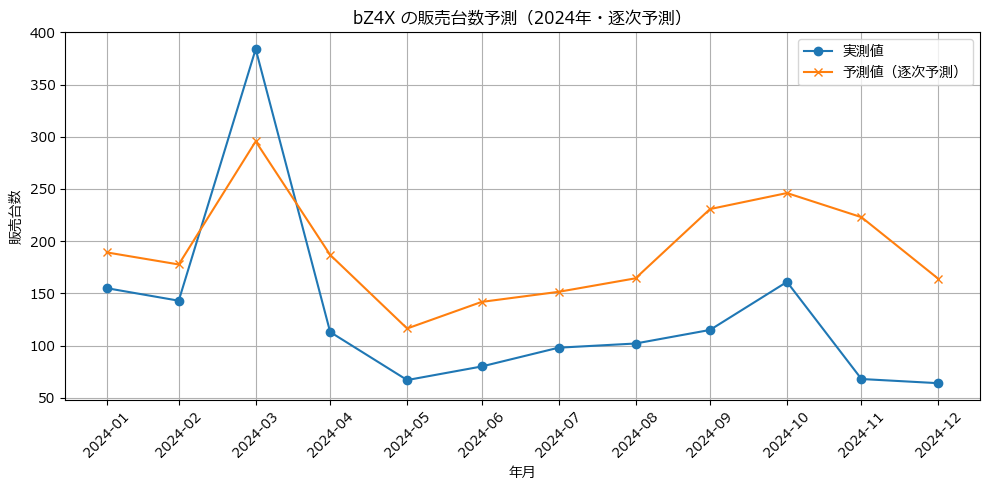


=== 特徴量重要度ランキング（全体） ===
                                        特徴量       重要度         カテゴリ
25                          diff_from_mean6  0.275169         経済指標
24                          diff_from_mean3  0.164387         経済指標
36                              yoy_diff_12  0.108699         経済指標
37                             yoy_ratio_12  0.063379         経済指標
19                        yoy_growth_base12  0.060804       前年比成長率
101                          経済指標＿ドイツ_自動車支出  0.026963         経済指標
80                         経済指標＿ドイツ_ZEW現在の値  0.026459         経済指標
44                                  month_8  0.023768       季節性ダミー
20                           rolling_mean_3  0.019912  移動平均・移動標準偏差
8                                     lag_6  0.018829        ラグ特徴量
3                                     lag_1  0.011628        ラグ特徴量
66   先輩の論文_ドイツ語ver_Energiemanagement: (ドイツ)  0.011114         経済指標
96                          経済指標＿ドイツ_景気楽観指数  0.010707         経済指標
21                            rolling

C:\Users\81802\AppData\Local\Temp\ipykernel_21360\2358578461.py:1019: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  calendar_months = pd.date_range("2024-01-01", "2024-12-31", freq="M")


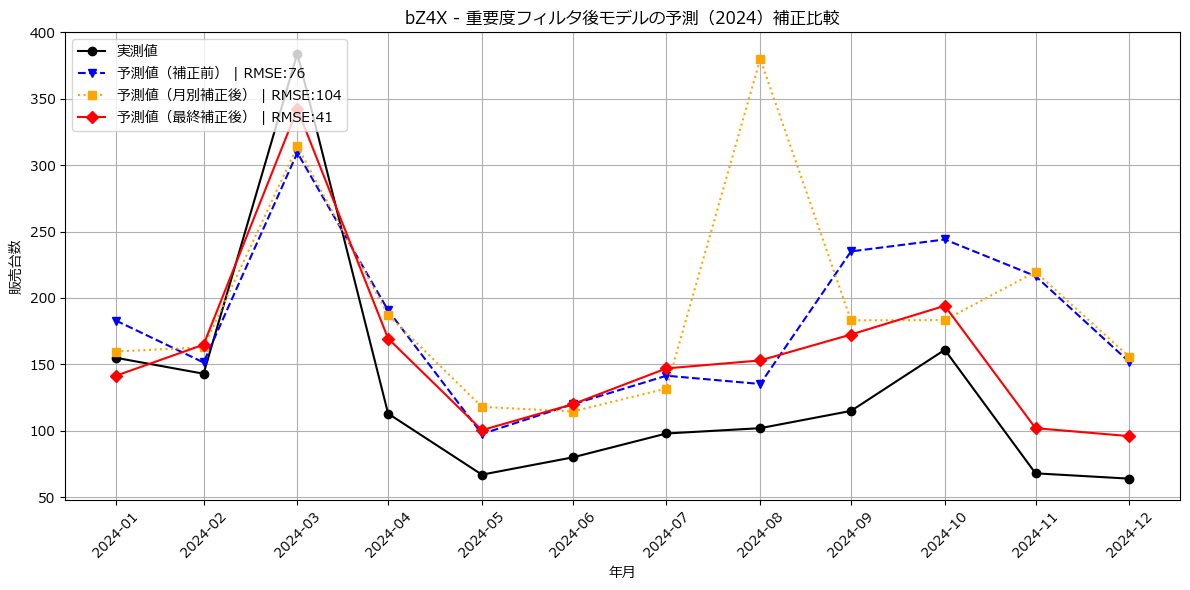


=== 最終予測結果（補正前のみ） ===
           年月  実測値（販売台数）  予測値（補正前）  誤差（補正前）  絶対誤差（補正前）  APE（補正前）(%)
0  2024-01-31      155.0    183.06   -28.06      28.06        18.10
1  2024-02-29      143.0    151.46    -8.46       8.46         5.92
2  2024-03-31      384.0    309.37    74.63      74.63        19.43
3  2024-04-30      113.0    190.69   -77.69      77.69        68.75
4  2024-05-31       67.0     97.61   -30.61      30.61        45.69
5  2024-06-30       80.0    119.97   -39.97      39.97        49.96
6  2024-07-31       98.0    141.49   -43.49      43.49        44.38
7  2024-08-31      102.0    135.27   -33.27      33.27        32.62
8  2024-09-30      115.0    235.08  -120.08     120.08       104.41
9  2024-10-31      161.0    244.05   -83.05      83.05        51.59
10 2024-11-30       68.0    216.47  -148.47     148.47       218.34
11 2024-12-31       64.0    151.83   -87.83      87.83       137.23

=== 評価指標（補正前） ===
RMSE: 75.87
MAE : 64.63
MAPE: 66.37%


In [ ]:
#(確定版bZ4X)
#  --- 最終統合修正版：エラー対応、逐次予測ロジック（ラグ特徴量更新）実装済み ---

# 最終版：RandomForestモデル（変更なし）＋逐次予測＋重要度フィルタ後に対する
# 「月別平均残差(additive)」補正を適用し、補正前/補正後の評価・表・グラフを出力するスクリプト。

# 注意：
# - 補正は「重要度フィルタ後モデル（best_model_reduced）」のみに適用します（ユーザ指定）。
# - 学習・予測ロジックは元コードに準拠。ただし補正用に検証領域(val_period)をtrainの末尾から取得して
#   月別平均残差を算出します（過学習を避けるため val_period を適宜調整してください）。

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import glob
import os
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint
import chardet
import seaborn as sns
import matplotlib
from sklearn.linear_model import Ridge


# --- ユーザ設定 ---
sales_file = r"C:\Users\81802\Documents\会計\VSCode\ドイツ販売台数\卒業研究\ランダムフォレスト実装フォルダ\bZ4X.csv"
econ_folder = r"C:\Users\81802\Documents\会計\VSCode\ドイツ販売台数\卒業研究\ランダムフォレスト実装フォルダ\経済指標まとめ" # フォルダ名を修正
# ターゲットモデル（必要に応じて変更）
target_model =  "bZ4X" # "TOYOTA合計" "TOYOTA電動車" "bZ4X"　　# ターゲットモデル

# --- エンコーディング自動判定関数 (文字化け対策版) ---
def read_csv_autoencoding(path):
    
    # 🌟 修正ポイント: 日本語Windows CSVファイルの標準である cp932 を最優先で試す
    try:
        # cp932 (Shift JISの拡張版) で読み込みを試行
        return pd.read_csv(path, encoding="cp932")
    except UnicodeDecodeError:
        # cp932で失敗した場合、chardetでエンコーディングを再判定
        with open(path, "rb") as f:
            result = chardet.detect(f.read(10000))
        enc = result["encoding"] or "utf-8"
        
        try:
            # chardet が検出したエンコーディングで再試行
            print(f"[INFO] {path} にて {enc} を試行中...")
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            # 最終的なフォールバックとして UTF-8 を試行
            return pd.read_csv(path, encoding="utf-8")

# --- 1. 販売データ読み込みと整形 ---
df = pd.read_csv(sales_file, encoding="utf-8")
id_cols = ["モデル", "パワートレイン"]
date_cols = [col for col in df.columns if col.strip().isdigit()]
long_df = df[id_cols + date_cols].melt(id_vars=id_cols, var_name="年月", value_name="販売台数")
long_df["年月"] = pd.to_datetime(long_df["年月"].astype(str) + "01", format="%Y%m%d") + pd.offsets.MonthEnd(0)
long_df["販売台数"] = pd.to_numeric(long_df["販売台数"], errors="coerce")
long_df.dropna(subset=["販売台数"], inplace=True)

# --- 2. 経済指標CSVを読み込んで特徴量化 (確実な構造に基づく最終修正版) ---
econ_files = sorted(glob.glob(os.path.join(econ_folder, "*.csv")))
econ_dfs = []

# ★ 修正ポイント: 全ファイル共通の構造（1列目: date, 2列目以降: 特徴量）を前提とする
for f in econ_files:
    tmp = read_csv_autoencoding(f)
    colname = os.path.splitext(os.path.basename(f))[0]
    
    # --- 1. 日付列の特定とリネーム ---
    # 最初の列（date/DateTimeなど）を日付列として特定
    date_col = tmp.columns[0]
    tmp.rename(columns={date_col: "年月"}, inplace=True)
    
    # --- 2. 日付の整形とマージキー作成 ---
    # すべてのファイルで YYYYMM 形式（例: 202001）を前提として処理
    tmp["年月"] = pd.to_datetime(tmp["年月"].astype(str), format="%Y%m", errors="coerce")
    tmp = tmp.dropna(subset=["年月"])
    
    # 年月をマージキー（月次末日ベース）に変換
    tmp["YearMonth"] = tmp["年月"] + pd.offsets.MonthEnd(0)
    
    # --- 3. 特徴量（値）の抽出と整形 ---
    # 日付列を除いた全ての列を特徴量として扱う
    value_cols = [c for c in tmp.columns if c not in ["年月", "YearMonth"]]
    
    if len(value_cols) == 0:
        print(f"[WARNING] 経済指標ファイル {f} に値の列が見つかりません。スキップします。")
        continue

    # 複数列の特徴量を melt して、ファイル名を接頭辞として付与
    mon = tmp.melt(id_vars=["YearMonth"], value_vars=value_cols, var_name="FeatureName", value_name="Value")
    
    # 特徴量名とファイル名を組み合わせてユニークな列名を作成
    # 例: 経済指標＿ドイツ_GDP, toyota_all_web検索数_トヨタ・ヤリス: (ドイツ)
    mon["NewColName"] = colname + "_" + mon["FeatureName"]
    
    # YearMonth ごとに特徴量を pivot し、複数の特徴量を持つデータフレームを作成
    mon_pivot = mon.pivot_table(
        index="YearMonth", 
        columns="NewColName", 
        values="Value", 
        aggfunc="last" # 月内の値が複数あった場合、最後の値を使用
    ).reset_index()
    
    econ_dfs.append(mon_pivot)

# --- 3. データ統合と対象モデルの抽出 ---
# ... (以降のコードは、前回の修正版の内容をそのまま使用してください) ...
group = long_df[long_df["モデル"] == target_model].sort_values("年月").copy()

if group.shape[0] == 0:
    raise ValueError(f"対象モデル '{target_model}' の行が見つかりません。モデル名を確認してください。")

# group に YearMonth を作成（マージキー）
group["YearMonth"] = group["年月"].dt.to_period("M").dt.to_timestamp("M")

# 経済指標の統合
if econ_dfs:
    # ★ 修正ポイント: 複数のデータフレームをYearMonthをキーにマージ
    econ_all = econ_dfs[0]
    for df_e in econ_dfs[1:]:
        econ_all = econ_all.merge(df_e, on="YearMonth", how="outer")
    
    econ_all.sort_values("YearMonth", inplace=True)
    # FutureWarning の解消
    econ_all.ffill(inplace=True) 
    econ_all.bfill(inplace=True)
else:
    econ_all = pd.DataFrame(columns=["YearMonth"])

# group と econ_all を結合 (残りのコードはそのまま)
merged = group.merge(econ_all, on="YearMonth", how="left")

# 年月ごとに集計（重複回避）
# 以前の MergeError/KeyError を解消するための修正ロジック
model_df = merged.groupby(["年月", "YearMonth"], as_index=False).agg({"販売台数": "sum"})
# 経済指標も再統合（YearMonthをキーに結合）
# YearMonthをキーに結合するため、重複するYearMonthを持つ行を削除
econ_cols_to_merge = econ_all.columns.tolist()
if "YearMonth" in econ_cols_to_merge:
    econ_cols_to_merge.remove("YearMonth")

merged_econ_for_model_df = merged.drop(columns=["モデル", "パワートレイン", "販売台数", "年月"]).drop_duplicates(subset=["YearMonth"])
model_df = model_df.merge(merged_econ_for_model_df, on="YearMonth", how="left")

# 欠損値処理
model_df.fillna(0, inplace=True) 

# --- 4. 特徴量作成 ---
model_df["year"] = model_df["YearMonth"].dt.year
model_df["month"] = model_df["YearMonth"].dt.month
model_df["time_index"] = (model_df["YearMonth"] - model_df["YearMonth"].min()).dt.days

# # ラグ特徴量（過去の販売台数）
for lag in [1,2,3,4,5,6,7,8,9,10,11,12]:
    model_df[f"lag_{lag}"] = model_df["販売台数"].shift(lag)

# # 前年比成長率
model_df["yoy_growth1"]  = (model_df["lag_1"]  / model_df["lag_2"]  - 1)
model_df["yoy_growth3"]  = (model_df["lag_1"]  / model_df["lag_4"]  - 1)
model_df["yoy_growth6"]  = (model_df["lag_1"]  / model_df["lag_7"]  - 1)
model_df["yoy_growth12"] = (model_df["lag_1"]  / model_df["lag_12"] - 1)

# # 移動平均・移動標準偏差
model_df["rolling_mean_3"] = model_df["販売台数"].rolling(window=3).mean()
model_df["rolling_std_3"] = model_df["販売台数"].rolling(window=3).std()
model_df["rolling_mean_6"] = model_df["販売台数"].rolling(window=6).mean()
model_df["rolling_std_6"] = model_df["販売台数"].rolling(window=6).std()

# # 直近平均
model_df["avg_1_2"]  = model_df[["lag_1","lag_2"]].mean(axis=1)
model_df["avg_1_3"] = model_df[["lag_1", "lag_2", "lag_3"]].mean(axis=1)
model_df["avg_1_6"]  = model_df[[f"lag_{i}" for i in range(1,7)]].mean(axis=1)
model_df["avg_1_12"] = model_df[[f"lag_{i}" for i in range(1,13)]].mean(axis=1)

# 四半期末ダミー
model_df["quarter_end"] = model_df["month"].isin([3,6,9,12]).astype(int)




# 🌟【修正点④：トレンド・季節性・変動特徴量を追加】
# ==========================================================
# ① 時系列のトレンドを数値化（長期傾向）
model_df["trend_index"] = np.arange(len(model_df))

# ② 月の周期性をsin/cosで表現（12ヶ月周期の季節性）
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

# ③ 年始・半期ダミー
model_df["is_new_year"] = (model_df["month"] == 1).astype(int)
model_df["half_year"] = ((model_df["month"] - 1) // 6).astype(int)

# ④ 前年同月との比較（販売台数ベース）
model_df["yoy_diff_12"] = model_df["販売台数"] - model_df["販売台数"].shift(12)
model_df["yoy_ratio_12"] = model_df["販売台数"] / model_df["販売台数"].shift(12)
model_df["yoy_ratio_12"].replace([np.inf, -np.inf], np.nan, inplace=True)
model_df["yoy_ratio_12"].fillna(1, inplace=True)

# ⑤ 移動平均との差分（短期変動）
if "rolling_mean_3" in model_df.columns:
    model_df["diff_from_mean3"] = model_df["販売台数"] - model_df["rolling_mean_3"]
if "rolling_mean_6" in model_df.columns:
    model_df["diff_from_mean6"] = model_df["販売台数"] - model_df["rolling_mean_6"]

print("✅ トレンド・季節性・変動特徴量を追加しました。")



# --- 外生変数の1か月ラグを作成 ---
#for col in econ_cols:
#    model_df[f"{col}_lag1"] = model_df[col].shift(1)

# NaN除去 (特徴量作成後、一回だけ実行)
#model_df = model_df.dropna().reset_index(drop=True)

# ダミー変数
month_dummies = pd.get_dummies(model_df["month"], prefix="month", drop_first=True)
                               #False)
model_df = pd.concat([model_df, month_dummies], axis=1)

# --- トレンド補足：前年同月比（販売台数基準） ---
# 既存のyoy_growth12と重複するが、shift(12)ベースで別に保持
model_df["yoy_growth_base12"] = model_df["販売台数"].pct_change(12)

# --- 経済指標の変化率追加（存在する列にのみ適用） ---
for col in ["GDP", "CPI", "Unemployment", "EVsales"]:
    if col in model_df.columns:
        model_df[f"{col}_growth"] = model_df[col].pct_change().shift(1)

# --- NaN除去の改善 ---
# ⚠️ ここで「販売台数のラグ欠損」行（初期12ヶ月分）をdrop
lag_cols = [f"lag_{i}" for i in [1,2,3,6,12]]
model_df = model_df.dropna(subset=lag_cols).reset_index(drop=True)

# 経済指標など外生変数だけは安全に補完
model_df = model_df.fillna(method="ffill").fillna(method="bfill")

# --- 欠損補完（前後方向両方） ---
model_df = model_df.fillna(method="bfill").fillna(method="ffill")

# --- NaN除去（最終） ---
model_df = model_df.dropna().reset_index(drop=True)





# --- 5. 説明変数の確定 ---
all_features = [
    # --- 基本 ---
    "year", "month", "time_index",

    # --- ラグ特徴量 ---
    "lag_1","lag_2","lag_3","lag_4","lag_5","lag_6",
    "lag_7","lag_8","lag_9","lag_10","lag_11","lag_12",

    # --- 成長率・変化率 ---
    "yoy_growth1","yoy_growth3","yoy_growth6","yoy_growth12",
    "yoy_growth_base12",  # ★ 前年同月比（別計算）

    # --- 移動平均・変動 ---
    "rolling_mean_3","rolling_std_3","rolling_mean_6","rolling_std_6",
    "diff_from_mean3","diff_from_mean6",  # ★ 新規追加（短期変動）

    # --- 平均系列 ---
    "avg_1_2","avg_1_3","avg_1_6","avg_1_12",

    # --- 季節性・トレンド ---
    "trend_index",      # ★ 長期トレンド
    "month_sin","month_cos",  # ★ 周期性表現
    "quarter_end",
    "is_new_year","half_year",  # ★ 年始・半期ダミー

    # --- 前年同月差・比 ---
    "yoy_diff_12","yoy_ratio_12",  # ★ 12ヶ月比較
] + list(month_dummies.columns)

# # 経済指標列を動的に追加
econ_cols = [c for c in model_df.columns if c not in [
     "モデル", "パワートレイン", "年月", "販売台数", "YearMonth" # 日付列を除外
     ] + all_features]

# 経済指標列 + そのラグ列をすべて含める
econ_with_lags = []
for c in econ_cols:
    econ_with_lags.extend([c, f"{c}_lag1"])

feature_cols = list(dict.fromkeys(all_features + econ_cols))
print(f"[INFO] feature_cols の総数: {len(feature_cols)}")


# --- 6. 学習・テスト分割とデータクリーニング ---
# 学習データ: 2022年6月～2023年12月
train_mask = (model_df["YearMonth"] >= "2020-01-01") & (model_df["YearMonth"] <= "2023-12-31")
# テストデータ: 2024年（以前のエラー修正済み）
test_mask  = model_df["year"] == 2024

train_df = model_df[train_mask].copy()
test_df = model_df[test_mask].copy()

# データクリーニング関数
def clean_df(df, feature_cols):
    df = df.copy()
    # 🌟 修正ポイント1: NaN/inf を 0 ではなく、中央値に置換（より頑健な処理）
    for col in feature_cols:
        if df[col].dtype in [np.number]:
            # inf/-inf を NaN に変換
            df[col].replace([np.inf, -np.inf], np.nan, inplace=True)
            
            # 中央値（Median）を計算し、欠損値を埋める
            median_val = df[col].median()
            df[col].fillna(median_val if pd.notna(median_val) else 0, inplace=True)
            
            # 🌟 修正ポイント2: 極端な外れ値のクリッピング（上下1%と99%でクリップ）
            lower_bound = df[col].quantile(0.01)
            upper_bound = df[col].quantile(0.99)
            df[col] = df[col].clip(lower_bound, upper_bound)
            
            # 最後に再度 NaN/inf を 0 に置換 (念のため)
            df[col].replace([np.inf, -np.inf], 0, inplace=True)
            df[col].fillna(0, inplace=True)
            
    return df

# クリーニング
train_df = clean_df(train_df, feature_cols)
test_df = clean_df(test_df, feature_cols)
# # データクリーニング関数
# def clean_df(df, feature_cols):
#     df = df.copy()
#     # NaN/inf を 0 に置換
#     df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
#     # 極端な値のクリッピング（任意）
#     numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns
#     df[numeric_cols] = df[numeric_cols].clip(-1e10, 1e10)
#     return df

# # クリーニング
# train_df = clean_df(train_df, feature_cols)
# test_df = clean_df(test_df, feature_cols)

X_train_full = train_df[feature_cols]
y_train_full = train_df["販売台数"]
y_test_true = test_df["販売台数"].values
dates_test = test_df["年月"]


# --- 5.5 訓練データの時系列スプリット戦略 ---
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
print("✅ TimeSeriesSplitを使用した交差検証を設定しました。")


# --- 7. パラメータ探索とモデル学習（best_modelを決定） ---
param_dist = {
    "n_estimators": randint(50, 1001),
    "max_depth": randint(10, 50),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None, 0.5, 0.8],
    "bootstrap": [True],
    "max_samples": [None, 0.5, 0.8],
}

# ⚠️ エラー対策：学習データから日付型（DateTime）の列を強制的に削除
datetime_cols = X_train_full.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns
if len(datetime_cols) > 0:
    print(f"[ERROR FIX] 学習データから日付型の列を削除します: {datetime_cols.tolist()}")
    X_train_full = X_train_full.drop(columns=datetime_cols)
    
# feature_cols からも削除（予測時に入力されないように）
feature_cols = [c for c in feature_cols if c not in datetime_cols]


n_samples = len(X_train_full)
n_splits = min(5, n_samples - 1)

if n_splits < 2:
    best_model = RandomForestRegressor(random_state=42)
    best_model.fit(X_train_full, y_train_full)
else:
    #tscv = TimeSeriesSplit(n_splits=n_splits)
    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        param_distributions=param_dist,
        n_iter=50,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    search.fit(X_train_full, y_train_full)
    print("ベストパラメータ:", search.best_params_)
    best_model = search.best_estimator_

print("モデル学習完了。")


# --- 8. 逐次予測ループ（②対応済み） ---
preds = []
test_df["予測値"] = np.nan

# 訓練データの末尾12か月を履歴として保持
history_sales = train_df["販売台数"].iloc[-12:].tolist()

print("--- 逐次予測実行中（②・③修正版） ---")
for i in range(len(test_df)):
    current_month_df = test_df.iloc[[i]].copy()

    # ✅ lag_1を最新販売値で更新
    current_month_df["lag_1"] = history_sales[-1]

    # ✅ lag_2〜12を更新
    for lag in range(2,13):
        if len(history_sales) >= lag:
            current_month_df[f"lag_{lag}"] = history_sales[-lag]
    
    # ✅ 成長率の再計算（過去データ間の比）
    def safe_growth(n, d):
        return (n / d - 1) if d != 0 else 0

    # ✅ yoy_growth修正：訓練時と同様に「過去データ間の比」で算出
    if len(history_sales) >= 4:
        current_month_df["yoy_growth3"] = (history_sales[-1] / history_sales[-4] - 1)
    if len(history_sales) >= 7:
        current_month_df["yoy_growth6"] = (history_sales[-1] / history_sales[-7] - 1)
    if len(history_sales) >= 13:
        current_month_df["yoy_growth12"] = (history_sales[-1] / history_sales[-13] - 1)

    # ✅ 移動平均・標準偏差・平均の再計算
    if len(history_sales) >= 3:
        current_month_df["rolling_mean_3"] = np.mean(history_sales[-3:])
        current_month_df["rolling_std_3"]  = np.std(history_sales[-3:])
        current_month_df["avg_1_3"]        = np.mean(history_sales[-3:])
    if len(history_sales) >= 6:
        current_month_df["rolling_mean_6"] = np.mean(history_sales[-6:])
        current_month_df["rolling_std_6"]  = np.std(history_sales[-6:])
    if len(history_sales) >= 12:
        current_month_df["avg_1_12"] = np.mean(history_sales[-12:])

    # --- 予測 ---
    X_next = current_month_df[feature_cols].copy()
    X_next = current_month_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    y_pred = best_model.predict(X_next)[0]

    # --- 結果格納 ---
    test_df.loc[test_df.index[i], "予測値"] = y_pred
    history_sales.append(y_pred)

preds = test_df["予測値"].values



# --- 9. 評価と結果表示 ---
y_true = test_df["販売台数"].values
y_pred_vals = test_df["予測値"].values

# 評価指数
rmse = np.sqrt(np.mean((y_true - y_pred_vals)**2))
mae = np.mean(np.abs(y_true - y_pred_vals))
mape = np.mean(np.abs((y_true - y_pred_vals) / y_true)) * 100

print("\n=== 評価指数（2024年・逐次予測） ===")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")


# --- 月別集計結果 ---
results_df = test_df.copy()
results_df.rename(columns={"販売台数": "実測値（販売台数）", "予測値": "予測値（販売台数）"}, inplace=True)
results_df["年月"] = results_df["年月"].dt.strftime("%Y-%m")
results_df["誤差"] = results_df["実測値（販売台数）"] - results_df["予測値（販売台数）"]
results_df["絶対誤差"] = results_df["誤差"].abs()
results_df["APE(%)"] = results_df["絶対誤差"] / results_df["実測値（販売台数）"] * 100

results_df = results_df[[
    "年月", "実測値（販売台数）", "予測値（販売台数）", "誤差", "絶対誤差", "APE(%)"
]]

print("\n▼ 月別予測結果（逐次予測）")
print(results_df.round(2))


# --- 10. 可視化 ---
matplotlib.rcParams['font.family'] = 'Meiryo'
matplotlib.rcParams['axes.unicode_minus'] = False

x_data = results_df["年月"]
y_test_vals = results_df["実測値（販売台数）"].values
y_pred_vals_plot = results_df["予測値（販売台数）"].values

plt.figure(figsize=(10, 5))
plt.plot(dates_test, y_test_vals, label="実測値", marker='o', markersize=6)
plt.plot(dates_test, y_pred_vals_plot, label="予測値（逐次予測）", marker='x', markersize=6)
plt.title(f"{target_model} の販売台数予測（2024年・逐次予測）")
plt.xlabel("年月")
plt.ylabel("販売台数")
plt.xticks(
    pd.date_range("2024-01-01", "2024-12-31", freq="M"),
    [d.strftime("%Y-%m") for d in pd.date_range("2024-01-01", "2024-12-31", freq="M")],
    rotation=45
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- 11. 特徴量重要度の可視化（元のコードと同様） ---
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "特徴量": feature_cols,
    "重要度": importances
}).sort_values("重要度", ascending=False)

def categorize_feature(feat):
    if feat.startswith("lag_"):
        return "ラグ特徴量"
    elif feat.startswith("rolling_mean") or feat.startswith("rolling_std"):
        return "移動平均・移動標準偏差"
    elif feat.startswith("yoy_growth"):
        return "前年比成長率"
    elif feat.startswith("avg_1_"):
        return "直近平均"
    elif feat.startswith("month_") or feat == "quarter_end":
        return "季節性ダミー"
    elif feat in ["year", "month", "time_index"]:
        return "トレンド指標"
    else:
        return "経済指標"
    
feature_importance_df["カテゴリ"] = feature_importance_df["特徴量"].apply(categorize_feature)

print("\n=== 特徴量重要度ランキング（全体） ===")
print(feature_importance_df.head(20))




# --- 粒度別に "必ず" モデルを学習して、重要度を計算 ---
model_for_importance = RandomForestRegressor(random_state=42)
model_for_importance.fit(X_train_full, y_train_full)

# ここで粒度別の重要度を算出する（これが最重要）
importances = model_for_importance.feature_importances_
feature_importance_df = pd.DataFrame({
    "特徴量": X_train_full.columns,
    "重要度": importances
}).sort_values("重要度", ascending=False)




# # --- 12. 特徴量重要度ベースでの選択  ---
# # 🌟 修正点: 特徴量重要度の上位20個を選択するように変更
# NUM_TOP_FEATURES = 20
# important_features_list = feature_importance_df["特徴量"].head(NUM_TOP_FEATURES).tolist()

# # 必ず残すべき特徴量 (時系列モデルの基本)
# always_keep = [
#       "time_index", "year", "month", "quarter_end"]\
#     + [f"lag_{i}" for i in range(1, 13)]
# # ラグ特徴量を作成する過程で除外されることを防ぐため、必ず追加

# # 最終的な特徴量リストを作成（順序維持）
# # important_features = []
# # seen = set(important_features_list)
# # for col in feature_cols:
# #      if col in always_keep or col in seen:
# #          if col not in important_features:
# #              important_features.append(col)

# # # 最終的な特徴量リストを作成
# # # 選択された特徴量が feature_cols に含まれていることを確認し、リストを作成
# important_features = [col for col in top_20_features_list if col in feature_cols]

# # 念のため、最終的に学習に使用するX_train_fullのカラムに存在する特徴量に絞る
# important_features = [c for c in important_features if c in X_train_full.columns]




NUM_TOP_FEATURES = 20

# top20 の特徴量リストを作る
important_features = (
    feature_importance_df
    .sort_values("重要度", ascending=False)
    ["特徴量"]
    .head(NUM_TOP_FEATURES)
   .tolist()
)


print(f"\n選択された特徴量（{len(important_features)}個）:")
print(important_features)






# --- 13. 重要度フィルタ後のモデル再学習 ---
X_train_reduced = X_train_full[important_features].copy().astype(float)
y_train_reduced = y_train_full.copy()

# # --- 再度パラメータ探索 ---
param_dist_reduced = {
    "n_estimators": randint(50, 1001),
    "max_depth": randint(10, 50),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None, 0.5, 0.8],
    "bootstrap": [True],
    "max_samples": [None, 0.5, 0.8],
}

tscv_reduced = TimeSeriesSplit(n_splits=5)

search_reduced = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_reduced,
    n_iter=50,
    cv=tscv_reduced,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_reduced.fit(X_train_reduced, y_train_reduced)

print("✅ 重要度フィルタ後・再探索のベストパラメータ:", search_reduced.best_params_)

best_model_reduced = search_reduced.best_estimator_
print("✅ 重要度フィルタ後のモデル再学習完了")

#best_model_reduced.fit(X_train_reduced, y_train_reduced)
#print("✅ 重要度95%フィルタ後のモデル再学習完了")

# --- 14. 逐次予測ループ（修正版） ---
preds_reduced = []
test_df["予測値_reduced"] = np.nan

# ★修正点⑤: 訓練データ末尾12か月分の「実測値」を履歴として利用開始
history_sales_reduced = train_df["販売台数"].iloc[-12:].tolist()

print("\n--- 逐次予測実行中（ラグ更新＆動的特徴量再計算） ---")

for i in range(len(test_df)):
    current_month_df = test_df.iloc[[i]].copy()

    # ----------------------------------------------------
    # ★修正点⑥: 過去履歴を使って動的に特徴量を更新
    # ----------------------------------------------------
    if len(history_sales_reduced) > 0:
        # lag_1更新
        if "lag_1" in current_month_df.columns:
            current_month_df["lag_1"] = history_sales_reduced[-1]

        # lag_2〜12更新
        for lag in range(2, 13):
            col = f"lag_{lag}"
            if col in current_month_df.columns and len(history_sales_reduced) >= lag:
                current_month_df[col] = history_sales_reduced[-lag]

        # 移動平均・標準偏差・成長率など
        if len(history_sales_reduced) >= 3:
            if "rolling_mean_3" in current_month_df.columns:
                current_month_df["rolling_mean_3"] = np.mean(history_sales_reduced[-3:])
            if "avg_1_3" in current_month_df.columns:
                current_month_df["avg_1_3"] = np.mean(history_sales_reduced[-3:])
            if "rolling_std_3" in current_month_df.columns:
                current_month_df["rolling_std_3"] = np.std(history_sales_reduced[-3:])
            if "yoy_growth3" in current_month_df.columns:
                base = history_sales_reduced[-3]
                current_month_df["yoy_growth3"] = (history_sales_reduced[-1] / base - 1) if base != 0 else 0

        if len(history_sales_reduced) >= 6:
            if "rolling_mean_6" in current_month_df.columns:
                current_month_df["rolling_mean_6"] = np.mean(history_sales_reduced[-6:])
            if "avg_1_6" in current_month_df.columns:
                current_month_df["avg_1_6"] = np.mean(history_sales_reduced[-6:])
            if "rolling_std_6" in current_month_df.columns:
                current_month_df["rolling_std_6"] = np.std(history_sales_reduced[-6:])

        if len(history_sales_reduced) >= 12:
            if "avg_1_12" in current_month_df.columns:
                current_month_df["avg_1_12"] = np.mean(history_sales_reduced[-12:])
            if "yoy_growth12" in current_month_df.columns:
                base = history_sales_reduced[-12]
                current_month_df["yoy_growth12"] = (history_sales_reduced[-1] / base - 1) if base != 0 else 0

    # ----------------------------------------------------
    # ★修正点⑦: important_features のみ使用して予測
    # ----------------------------------------------------
    X_next = current_month_df[important_features].replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

    # 予測実行
    y_pred_reduced = best_model_reduced.predict(X_next)[0]

    # 結果格納
    test_df.loc[test_df.index[i], "予測値_reduced"] = y_pred_reduced
    history_sales_reduced.append(y_pred_reduced)

preds_reduced = test_df["予測値_reduced"].values
print("✅ 逐次予測完了（重要度フィルタ後）")

y_pred_reduced_vals = preds_reduced.copy()

# ----------------------
# --- 11. 補正＆アンダーシュート対策（重要度フィルタ後モデル） ---
# ----------------------
import numpy as np
import pandas as pd

# ========= 補正用ユーティリティ関数 =========

def compute_month_bias_from_validation(train_df, model, feature_list, val_period=12):
    """
    train_df: 学習データ（DataFrame）
    model: 学習済モデル（best_model_reduced 等）
    feature_list: 予測に使う特徴量リスト（important_features 等）
    val_period: train_df の末尾から検証に使う月数（例: 6, 12）
    戻り値: month_bias_dict（月->平均残差(実測-予測)）
    """
    # 直近 val_period ヶ月を検証領域にする
    if len(train_df) > val_period:
        val_df = train_df.iloc[-val_period:].copy()
    else:
        val_df = train_df.copy()

    X_val = (
        val_df[feature_list]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .astype(float)
    )

    val_pred = model.predict(X_val)
    val_true = val_df["販売台数"].values

    if "YearMonth" in val_df.columns:
        val_months = val_df["YearMonth"].dt.month.values
    else:
        val_months = val_df["年月"].dt.month.values

    resid = val_true - val_pred
    bias_df = pd.DataFrame({"month": val_months, "resid": resid})
    month_bias = bias_df.groupby("month")["resid"].mean().to_dict()
    return month_bias

def apply_month_bias_correction(preds, dates, month_bias_dict):
    corrected = []
    for p, d in zip(preds, dates):
        dt = pd.to_datetime(d, errors="coerce")
        if pd.isna(dt):
            m = None
        else:
            m = int(dt.month)
        bias = month_bias_dict.get(m, 0.0) if m is not None else 0.0
        corrected.append(p + bias)
    return np.array(corrected)

def asymmetric_weighted_rmse(y_true, y_pred, under_penalty=5.0):
    """
    下振れ（y_true > y_pred）に重いペナルティをかける RMSE。
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    resid = y_true - y_pred
    weights = np.where(resid > 0, 1.0 + under_penalty, 1.0)
    return np.sqrt(np.mean((resid * weights) ** 2))

def clip_asymmetric(original, corrected, lower_pct=-0.3, upper_pct=0.5):
    """
    下振れはある程度許容しつつ、上振れを抑えるための非対称クリップ。
    original: 実測値（y_test_true）を渡す。
    """
    clipped = []
    for o, c in zip(original, corrected):
        if o == 0:
            min_v, max_v = -1e6, 1e6
        else:
            min_v = o * (1 + lower_pct)
            max_v = o * (1 + upper_pct)
        clipped.append(min(max(c, min_v), max_v))
    return np.array(clipped)

# ========= Step1: 月別バイアスを計算 =========

val_period = 12
month_bias_reduced = compute_month_bias_from_validation(
    train_df, best_model_reduced, important_features, val_period=val_period
)
print("[月別バイアス（フィルタ後モデル, val）]:", month_bias_reduced)

# train 全体の in-sample 残差も使って欠損月を補完
train_preds_red = best_model_reduced.predict(X_train_reduced)
train_resid = y_train_reduced.values - train_preds_red
if "YearMonth" in train_df.columns:
    train_months = train_df["YearMonth"].dt.month.values
else:
    train_months = train_df["年月"].dt.month.values

train_bias_df = pd.DataFrame({"month": train_months, "resid": train_resid})
train_month_bias = train_bias_df.groupby("month")["resid"].mean().to_dict()
overall_mean_resid = np.mean(list(train_month_bias.values())) if len(train_month_bias) > 0 else 0.0

filled_month_bias = {}
for m in range(1, 13):
    if m in month_bias_reduced:
        filled_month_bias[m] = month_bias_reduced[m]
    elif m in train_month_bias:
        filled_month_bias[m] = train_month_bias[m]
    else:
        filled_month_bias[m] = overall_mean_resid

# 少しだけ滑らかにする（線形補間）※完全に決定論的
mb_series = pd.Series(filled_month_bias)
mb_full = mb_series.reindex(range(1, 13))
mb_full = mb_full.interpolate(method="linear", limit_direction="both")
mb_full = mb_full.fillna(mb_full.mean())
month_bias_reduced = mb_full.to_dict()

print("=== 補完後 month_bias_reduced (1..12) ===")
for m in range(1, 13):
    print(f"month {m:02d}: {month_bias_reduced[m]:.3f}")

# ========= Step2: 月別補正を適用（ベース予測） =========

base_preds_before = y_pred_reduced_vals  # 逐次予測（フィルタ後）のそのまま
y_pred_month = apply_month_bias_correction(base_preds_before, dates_test, month_bias_reduced)

# ========= Step3: 残差トレンド（Ridge）で “上振れ方向” の補正ベクトルを作る =========

resid_train = y_train_reduced.values - best_model_reduced.predict(X_train_reduced)

bias_feats_train = pd.DataFrame(
    {
        "time_index": train_df["time_index"].values,
        "month_sin": train_df["month_sin"].values,
        "month_cos": train_df["month_cos"].values,
    }
)

bias_model = Ridge(alpha=0.1, random_state=42)
#bias_model = Ridge(alpha=1.0, random_state=42)
bias_model.fit(bias_feats_train, resid_train)

bias_feats_test = pd.DataFrame(
    {
        "time_index": test_df["time_index"].values,
        "month_sin": test_df["month_sin"].values,
        "month_cos": test_df["month_cos"].values,
    }
)
trend_test = bias_model.predict(bias_feats_test)  # 補正ベクトル（正負両方ありうる）


# ===== 予測値と補正ベクトルの長さを揃える =====

# y_pred_month → test_df の長さに合わせているが、明示的に確保
n_test = len(y_pred_month)

trend_test_trim = trend_test[:n_test]  # trend側が多い場合は切る
# ※逆に trend のほうが少ない場合は pad が必要だが、基本的に trend>=pred

# デバッグ表示
print("len(y_pred_month) =", len(y_pred_month))
print("len(trend_test_trim) =", len(trend_test_trim))



# ========= Step4: “アンダーシュートを減らす” 方向で s を探索 =========
#  s は 0.1〜3.0 の範囲で取り、under_penalty を固定して
#  「加重RMSE が最小の±5%以内」で「下振れ合計が最小」な s を選ぶ。

under_penalty = 10.0     #5.0,
s_candidates = np.linspace(0.1,5,101)  # 0 は許さず、必ず少しは補正を効かせる

best_s = None
best_loss = np.inf

for s in s_candidates:
    y_pred_s = y_pred_month + s * trend_test_trim  # ← 長さ揃えたものを使う
    loss = asymmetric_weighted_rmse(y_test_true[:n_test], y_pred_s, under_penalty=under_penalty)
    
    if loss < best_loss:
        best_loss = loss
        best_s = s

print(f"改良版 tuning -> best_s={best_s:.3f}, weighted_loss={best_loss:.3f}")

print(f"asymmetric tuning -> best_s={best_s:.3f}, loss={best_loss:.3f}, sum_under={best_under:.1f}")

# ========= Step5: s を適用し、クリップで暴走を抑える =========

y_pred_final = y_pred_month + best_s * trend_test
y_pred_final_clipped = clip_asymmetric(y_test_true, y_pred_final, lower_pct=-0.3, upper_pct=0.5)

# ========= Step6: 評価指標を計算 =========
#  ⭐ 評価指標 (RMSE / MAE / MAPE) をまとめて出力 ⭐
# ============================

def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_true_safe = np.where(y_true == 0, 1e-6, y_true)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    return rmse, mae, mape

rmse_before, mae_before, mape_before = calc_metrics(y_test_true, y_pred_reduced_vals)
rmse_month, mae_month, mape_month = calc_metrics(y_test_true, y_pred_month)
rmse_final, mae_final, mape_final = calc_metrics(y_test_true, y_pred_final_clipped)

print("\n【最終補正後】")
print(f" RMSE : {rmse_final:.2f}")
print(f" MAE  : {mae_final:.2f}")
print(f" MAPE : {mape_final:.2f}%")
print("=====================================================================")


# ========= Step7: 結果を test_df & 表・グラフに反映 =========

test_df["予測値_reduced_month"] = y_pred_month
test_df["予測値_reduced_final"] = y_pred_final
test_df["予測値_reduced_final_clipped"] = y_pred_final_clipped

results_df_reduced = pd.DataFrame(
    {
        "年月": dates_test.dt.strftime("%Y-%m"),
        "実測値（販売台数）": y_test_true,
        "予測値（補正前）": y_pred_reduced_vals,
        "予測値（月別補正後）": y_pred_month,
        "予測値（最終補正後）": y_pred_final_clipped,
    }
)
results_df_reduced["誤差(補正前)"] = (
    results_df_reduced["実測値（販売台数）"] - results_df_reduced["予測値（補正前）"]
)
results_df_reduced["誤差(最終補正後)"] = (
    results_df_reduced["実測値（販売台数）"] - results_df_reduced["予測値（最終補正後）"]
)
results_df_reduced["絶対誤差(最終補正後)"] = results_df_reduced["誤差(最終補正後)"].abs()
results_df_reduced["APE(%)_final"] = (
    results_df_reduced["絶対誤差(最終補正後)"]
    / results_df_reduced["実測値（販売台数）"].replace(0, np.nan)
    * 100
)
results_df_reduced = results_df_reduced.fillna(0)

print("\n▼ 月別予測結果（重要度フィルタ後・補正比較）")
print(results_df_reduced.round(2))

# ========= グラフ（再起動前のイメージに近い形） =========

plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test_true, label="実測値", color="black", marker="o")
plt.plot(
    dates_test,
    y_pred_reduced_vals,
    label=f"予測値（補正前） | RMSE:{rmse_before:.0f}",
    color="blue",
    linestyle="--",
    marker="v",
)
plt.plot(
    dates_test,
    y_pred_month,
    label=f"予測値（月別補正後） | RMSE:{rmse_month:.0f}",
    color="orange",
    linestyle=":",
    marker="s",
)
plt.plot(
    dates_test,
    y_pred_final_clipped,
    label=f"予測値（最終補正後） | RMSE:{rmse_final:.0f}",
    color="red",
    linestyle="-",
    marker="D",
)

plt.title(f"{target_model} - 重要度フィルタ後モデルの予測（2024）補正比較")
plt.xlabel("年月")
plt.ylabel("販売台数")
calendar_months = pd.date_range("2024-01-01", "2024-12-31", freq="M")
plt.xticks(calendar_months, [d.strftime("%Y-%m") for d in calendar_months], rotation=45)
plt.grid(True)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 最終評価を一行で出す（補正後のみ）
#print(f"\n=== 重要度フィルタ後モデル（補正後） ===\nRMSE: {rmse_a:.2f}, MAE: {mae_a:.2f}, MAPE: {mape_a:.2f}%")

# # === 重要度フィルタ後モデル（最終補正後） ===
# rmse_a = np.sqrt(mean_squared_error(y_true, y_pred_final_clipped))
# mae_a = mean_absolute_error(y_true, y_pred_final_clipped)
# mape_a = np.mean(np.abs((y_true - y_pred_final_clipped) / y_true)) * 100

# print("\n=== 評価指数（重要度フィルタ後・最終補正後） ===")
# print(f"RMSE: {rmse_a:.2f}")
# print(f"MAE : {mae_a:.2f}")
# print(f"MAPE: {mape_a:.2f}%")

# # ======================================================
# #  📌 最終予測結果を DataFrame で出力（修正版：赤線＝最終補正後）
# # ======================================================

# # numpy → Series に変換（赤線：最終補正後）
# y_test_true_series = pd.Series(y_test_true)
# y_pred_final_series = pd.Series(y_pred_final_clipped)  # ←ここが重要！

# df_result = pd.DataFrame({
#     "年月": dates_test.reset_index(drop=True),
#     "実測値（販売台数）": y_test_true_series,
#     "予測値（最終補正後）": y_pred_final_series,
# })

# # 誤差 = 実測 - 予測
# df_result["誤差"] = df_result["実測値（販売台数）"] - df_result["予測値（最終補正後）"]

# # 絶対誤差
# df_result["絶対誤差"] = df_result["誤差"].abs()

# # APE
# df_result["APE(%)"] = df_result["絶対誤差"] / df_result["実測値（販売台数）"] * 100

# print("\n=== 最終予測結果（赤線：最終補正後） ===")
# print(df_result.round(2))



# ======================================================
#  📌 最終予測結果（補正前のみ・評価指標つき）を DataFrame で出力
# ======================================================

# numpy → Series に変換（補正前の青線）
y_test_true_series = pd.Series(y_test_true)
y_pred_before_series = pd.Series(y_pred_reduced_vals)  # ←補正前（青線）

df_result_before = pd.DataFrame({
    "年月": dates_test.reset_index(drop=True),
    "実測値（販売台数）": y_test_true_series,
    "予測値（補正前）": y_pred_before_series,
})

# 誤差 = 実測 - 補正前予測
df_result_before["誤差（補正前）"] = (
    df_result_before["実測値（販売台数）"] - df_result_before["予測値（補正前）"]
)

# 絶対誤差
df_result_before["絶対誤差（補正前）"] = df_result_before["誤差（補正前）"].abs()

# APE（%）
df_result_before["APE（補正前）(%)"] = (
    df_result_before["絶対誤差（補正前）"] 
    / df_result_before["実測値（販売台数）"] * 100
)


# ============================
#  📌 評価指標 (RMSE / MAE / MAPE)
# ============================

rmse_b = np.sqrt(mean_squared_error(y_test_true, y_pred_reduced_vals))
mae_b = mean_absolute_error(y_test_true, y_pred_reduced_vals)
mape_b = np.mean(np.abs((y_test_true - y_pred_reduced_vals) / y_test_true)) * 100

print("\n=== 最終予測結果（補正前のみ） ===")
print(df_result_before.round(2))

print("\n=== 評価指標（補正前） ===")
print(f"RMSE: {rmse_b:.2f}")
print(f"MAE : {mae_b:.2f}")
print(f"MAPE: {mape_b:.2f}%")



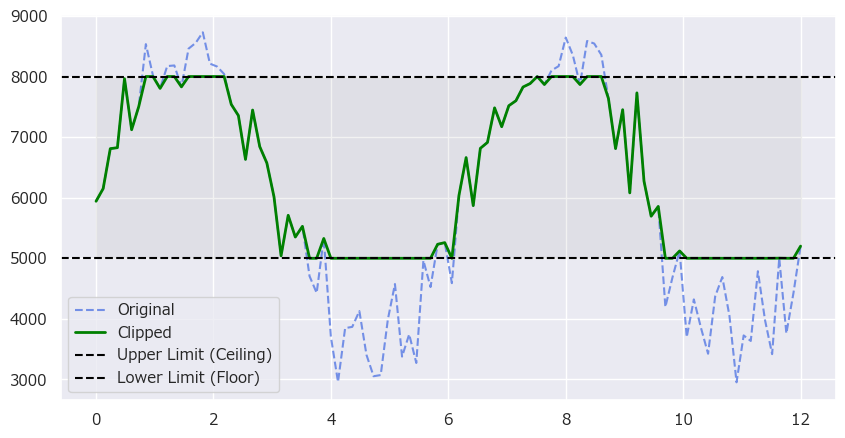

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# データの作成
x = np.linspace(0, 12, 100)
y_raw = 6000 + 2500 * np.sin(x) + np.random.normal(0, 500, 100) # 元の予測値（ノイズあり）

# クリップ処理の設定
upper_limit = 8000
lower_limit = 5000
y_clipped = np.clip(y_raw, lower_limit, upper_limit) # ここで一括処理

# 描画
plt.figure(figsize=(10, 5))
plt.plot(x, y_raw, linestyle='--', color='royalblue', label='Original', alpha=0.7)
plt.plot(x, y_clipped, color='green', linewidth=2, label='Clipped')
plt.axhline(upper_limit, color='black', linestyle='--', label='Upper Limit (Ceiling)')
plt.axhline(lower_limit, color='black', linestyle='--', label='Lower Limit (Floor)')
plt.fill_between(x, lower_limit, upper_limit, color='gray', alpha=0.1) # 正常範囲の塗りつぶし

plt.legend()
plt.show()